# ETF Multi-Horizon Direction / Return Prediction with Deep Learning and Feature Selection

This Kaggle notebook is a redesigned version of the uploaded ETF prediction code. It focuses on a more realistic financial-ML task:

- predict ETF **direction** for 1-day, 5-day, and 10-day horizons;
- keep **forward return regression** as a secondary diagnostic;
- compare classical ML baselines with deep-learning models;
- add **train-only feature selection** to reduce noisy/redundant predictors;
- use chronological train/validation/test splits to reduce look-ahead bias.

## Literature-to-code summary

| Paper | What it contributes | How this notebook uses the idea |
|---|---|---|
| Zhong & Enke, *Financial Innovation* | Predicts daily return direction of SPY using many financial/economic features and neural networks / hybrid ML. | Direction classification is the primary task; SPY can be one of the target ETFs. |
| Zhang, Zhao & Lin, *European Journal of Finance* | ETF price-trend prediction with image-based attention CNN and trading evaluation. | Uses deep learning for direction/trend and evaluates a simple trading strategy, although this notebook keeps tabular/sequence inputs rather than image inputs. |
| Shih et al., *Mathematics* | Compares ANN/LSTM/GRU/CNN-style deep-learning models with Fama-French-style factors for daily ETF return prediction. | Implements ANN/MLP, LSTM, GRU, and CNN-LSTM-style models; allows extra factor columns if they exist in your CSV. |
| Lim et al., *International Journal of Forecasting* | Temporal Fusion Transformer combines recurrent local processing with attention for multi-horizon forecasting. | Adds a simplified attention model inspired by TFT, not a full production TFT implementation. |
| Piovezan et al., *Computational Economics* | ETF return-direction forecasting with ML and trading-strategy evaluation. | Includes classical ML baselines and strategy diagnostics so deep learning is not evaluated alone. |

## Important modeling choice

Exact daily ETF returns are noisy and often have very low signal-to-noise ratio. So the main output is directional probability:

$$P(r_{t,t+h} > 0 \mid \mathcal{F}_t).$$

The forward log return is still saved for strategy and regression diagnostics:

$$r_{t,t+h}=\log(P_{t+h})-\log(P_t).$$

In [16]:
# ============================================================
# 0. Imports and configuration
# ============================================================

import os
import gc
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, mean_absolute_error, mean_squared_error, r2_score
)

import torch
import torch.nn as nn
import time 
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Kaggle data path
# -----------------------------
DATA_PATH = '/kaggle/input/datasets/ngc6523/raw-prices/adjusted_close_prices.csv'

# Fallback for local testing outside Kaggle
if not os.path.exists(DATA_PATH):
    local_fallback = "/mnt/data/adjusted_close_prices.csv"
    if os.path.exists(local_fallback):
        DATA_PATH = local_fallback

# -----------------------------
# Experiment settings
# -----------------------------
# Set to None to use all numeric columns except Date.
TARGET_TICKERS = ["SPY", "QQQ", "GLD", "VOO"]

HORIZONS = [1, 5, 10]
LAG_DAYS = 20
LOOKBACK = 30

VAL_SIZE = 0.15
TEST_SIZE = 0.20

# Feature selection. Options: "none", "correlation", "mutual_info", "rf_importance"
FEATURE_SELECTION_METHOD = "mutual_info"
MAX_SELECTED_FEATURES = 80
CORR_THRESHOLD = 0.95

# Model switches
RUN_CLASSICAL_MODELS = True
RUN_DEEP_MODELS = True
RUN_RETURN_REGRESSION_BASELINE = True

# Deep learning controls
SHOW_EPOCH_LOGS = False
EPOCHS = 50
PATIENCE = 8
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.25

# Runtime limiter for quick debugging. Set to None for all combinations.
MAX_TARGET_HORIZON_COMBOS = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Data path:", DATA_PATH)

Device: cpu
Data path: /kaggle/input/datasets/ngc6523/raw-prices/adjusted_close_prices.csv


## 1. Load adjusted-close prices

Expected CSV format:

```text
Date | SPY | QQQ | GLD | VOO | optional extra ETF/factor columns...
```

The code will use the specified `TARGET_TICKERS` as prediction targets. Extra numeric columns can still be used as predictors if you include them in the CSV.

In [17]:
# ============================================================
# 1. Load data
# ============================================================

prices_raw = pd.read_csv(DATA_PATH)

if "Date" not in prices_raw.columns:
    raise ValueError("Expected a Date column in the CSV.")

prices_raw["Date"] = pd.to_datetime(prices_raw["Date"])
prices_raw = prices_raw.sort_values("Date").set_index("Date")

# Keep numeric columns only.
prices = prices_raw.select_dtypes(include=[np.number]).copy()
prices = prices.replace([np.inf, -np.inf], np.nan).ffill().dropna(axis=0, how="any")

if TARGET_TICKERS is None:
    TARGET_TICKERS = list(prices.columns)
else:
    missing = [t for t in TARGET_TICKERS if t not in prices.columns]
    if missing:
        raise ValueError(f"Missing target ticker columns: {missing}. Available numeric columns: {prices.columns.tolist()}")

print("Price shape:", prices.shape)
print("Date range:", prices.index.min(), "to", prices.index.max())
print("Columns used as available inputs:", prices.columns.tolist())
print("Targets:", TARGET_TICKERS)

display(prices.reset_index().head())

Price shape: (2766, 4)
Date range: 2015-01-02 00:00:00 to 2025-12-31 00:00:00
Columns used as available inputs: ['SPY', 'QQQ', 'GLD', 'VOO']
Targets: ['SPY', 'QQQ', 'GLD', 'VOO']


,Date,SPY,QQQ,GLD,VOO
0,2015-01-02,170.124969,94.665085,114.080002,155.227417
1,2015-01-05,167.052597,93.276459,115.800003,152.500290
2,2015-01-06,165.479172,92.025764,117.120003,151.000732
3,2015-01-07,167.541214,93.212082,116.430000,152.887512
4,2015-01-08,170.514191,94.996155,115.940002,155.573578


## 2. Convert prices to log returns

Models are trained on return-based features, not raw prices, because price levels are usually nonstationary.

Return shape: (2765, 4)


,Date,SPY,QQQ,GLD,VOO
0,2015-01-05,-0.018225,-0.014777,0.014965,-0.017725
1,2015-01-06,-0.009463,-0.013499,0.011334,-0.009882
2,2015-01-07,0.012384,0.012809,-0.005909,0.012418
3,2015-01-08,0.017589,0.018959,-0.004217,0.017416
4,2015-01-09,-0.008046,-0.006605,0.011321,-0.008457


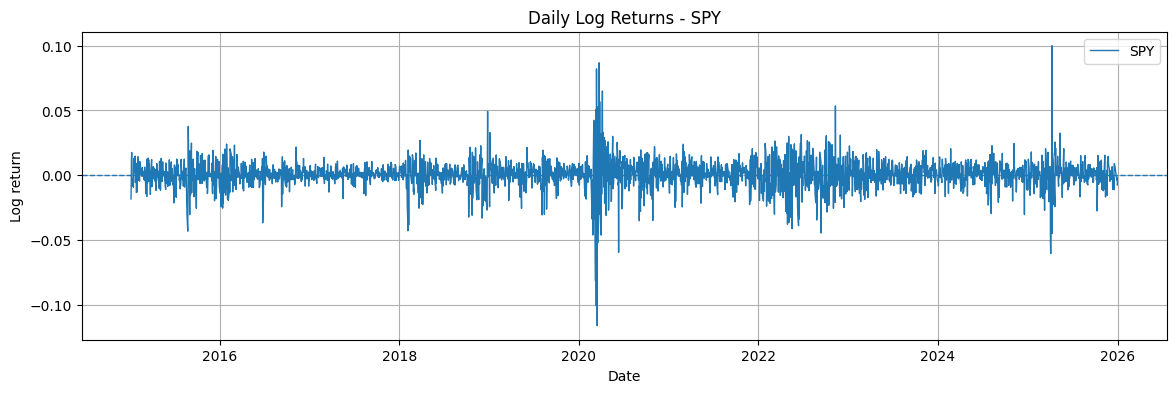

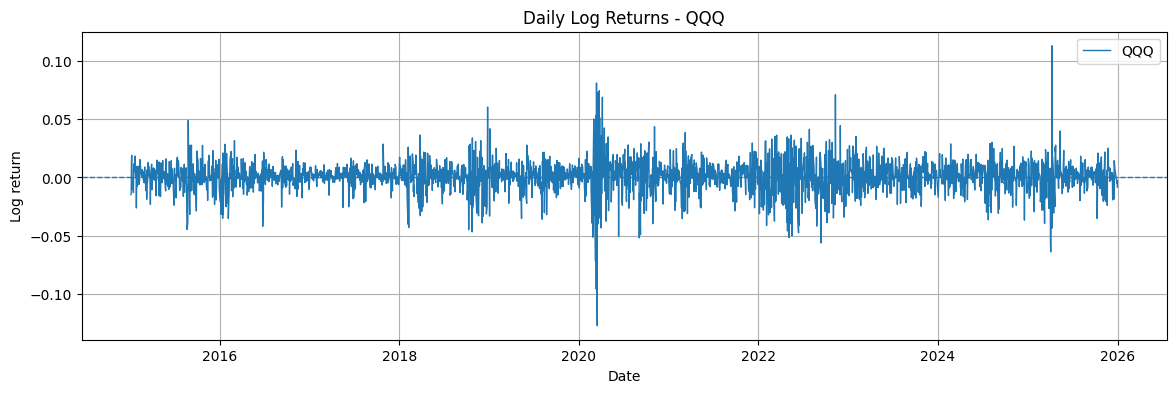

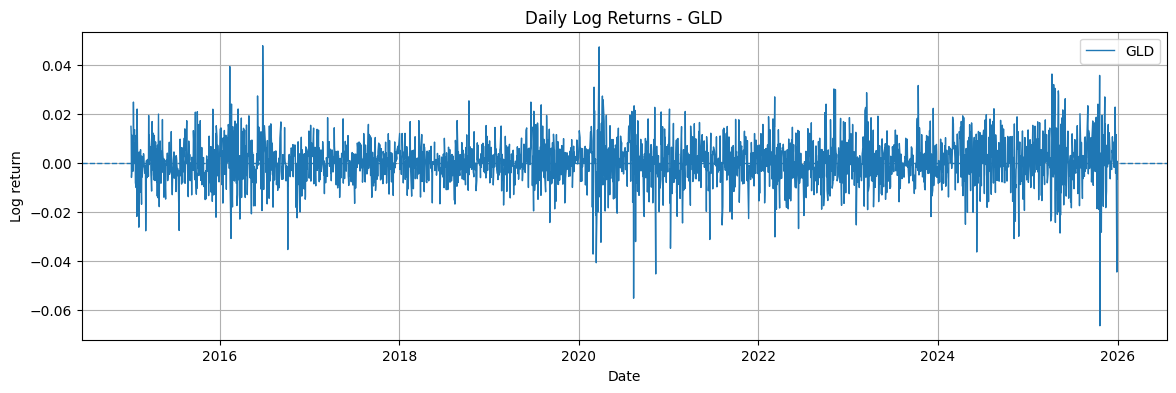

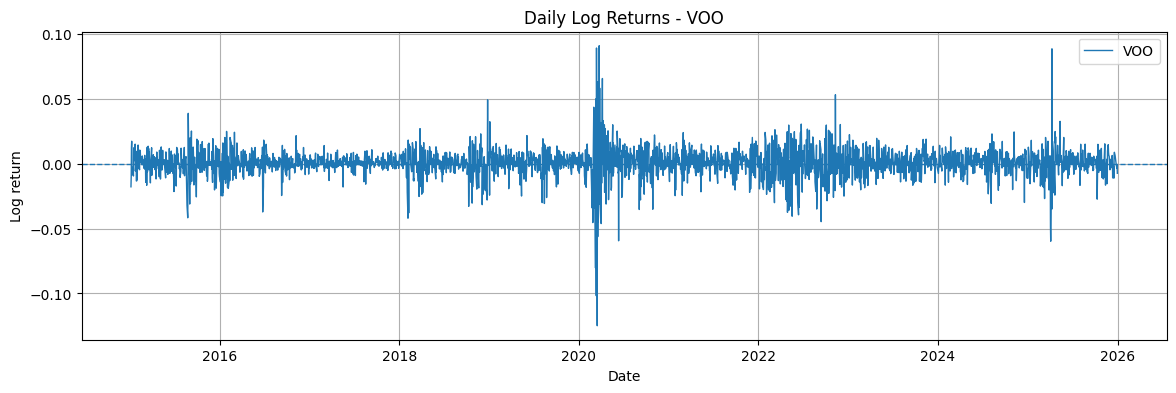

In [18]:
# ============================================================
# 2. Log returns
# ============================================================

log_prices = np.log(prices)
returns = log_prices.diff().replace([np.inf, -np.inf], np.nan).dropna()

print("Return shape:", returns.shape)
display(returns.reset_index().head())

for ticker in TARGET_TICKERS:
    plt.figure(figsize=(14, 4))
    plt.plot(returns.index, returns[ticker], label=ticker, linewidth=1)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Daily Log Returns - {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Log return")
    plt.legend()
    plt.grid(True)
    plt.show()

## 3. Feature engineering

Features are built using information available up to time $t$ only:

- lagged returns;
- rolling mean, volatility, min, max, skew;
- momentum over several windows;
- cross-sectional mean/dispersion across available ETFs/factors;
- rolling correlations between the target ETF and other available ETFs/factors.

The target is the future log return and the binary direction label.

In [19]:
# ============================================================
# 3. Feature engineering
# ============================================================

def make_features_for_target(prices, returns, target_ticker, horizon=1, lag_days=20):
    feature_df = pd.DataFrame(index=returns.index)

    # Lagged returns for all available columns.
    for col in returns.columns:
        for lag in range(1, lag_days + 1):
            feature_df[f"{col}_ret_lag_{lag}"] = returns[col].shift(lag)
        feature_df[f"{col}_ret_today"] = returns[col]

    # Rolling features.
    for col in returns.columns:
        r = returns[col]
        for window in [5, 10, 20, 60]:
            feature_df[f"{col}_roll_mean_{window}"] = r.rolling(window).mean()
            feature_df[f"{col}_roll_vol_{window}"] = r.rolling(window).std()
            feature_df[f"{col}_roll_min_{window}"] = r.rolling(window).min()
            feature_df[f"{col}_roll_max_{window}"] = r.rolling(window).max()
            feature_df[f"{col}_momentum_{window}"] = prices[col].pct_change(window)
        feature_df[f"{col}_roll_skew_20"] = r.rolling(20).skew()

    # Cross-sectional market features across all columns in the CSV.
    feature_df["cross_section_mean_return"] = returns.mean(axis=1)
    feature_df["cross_section_return_dispersion"] = returns.std(axis=1)
    feature_df["cross_section_positive_fraction"] = (returns > 0).mean(axis=1)

    # Target rolling correlations.
    for col in returns.columns:
        if col != target_ticker:
            feature_df[f"corr_{target_ticker}_{col}_20"] = returns[target_ticker].rolling(20).corr(returns[col])
            feature_df[f"corr_{target_ticker}_{col}_60"] = returns[target_ticker].rolling(60).corr(returns[col])

    forward_return = (log_prices[target_ticker].shift(-horizon) - log_prices[target_ticker]).rename("forward_return")
    direction = (forward_return > 0).astype(int).rename("direction")

    data = pd.concat([feature_df, forward_return, direction], axis=1)
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    X = data.drop(columns=["forward_return", "direction"])
    y_dir = data["direction"].astype(int)
    y_ret = data["forward_return"].astype(float)
    return X, y_dir, y_ret, data


def time_split(X, y_direction, y_return, val_size=0.15, test_size=0.20):
    n = len(X)
    test_start = int(n * (1 - test_size))
    val_start = int(test_start * (1 - val_size))
    return {
        "X_train": X.iloc[:val_start],
        "y_dir_train": y_direction.iloc[:val_start],
        "y_ret_train": y_return.iloc[:val_start],
        "X_val": X.iloc[val_start:test_start],
        "y_dir_val": y_direction.iloc[val_start:test_start],
        "y_ret_val": y_return.iloc[val_start:test_start],
        "X_test": X.iloc[test_start:],
        "y_dir_test": y_direction.iloc[test_start:],
        "y_ret_test": y_return.iloc[test_start:],
    }

## 4. Feature selection

Feature selection is applied **after the chronological split** and is fitted on the training period only.

Available methods:

- `none`: use all engineered features;
- `correlation`: remove highly correlated columns, then keep the first `MAX_SELECTED_FEATURES` columns;
- `mutual_info`: rank features by mutual information with the direction label;
- `rf_importance`: rank features by random-forest feature importance.

This is useful because ETF returns are noisy and many engineered lags/rolling features are redundant. Feature selection can reduce overfitting and speed up deep-learning training.

In [20]:
# ============================================================
# 4. Feature selection fitted on train only
# ============================================================

class TrainOnlyFeatureSelector:
    def __init__(self, method="mutual_info", max_features=80, corr_threshold=0.95, random_state=42):
        self.method = method
        self.max_features = max_features
        self.corr_threshold = corr_threshold
        self.random_state = random_state
        self.selected_features_ = None
        self.scores_ = None

    def fit(self, X_train, y_train):
        X = X_train.copy()
        y = np.asarray(y_train)

        if self.method == "none" or self.max_features is None:
            self.selected_features_ = list(X.columns)
            self.scores_ = pd.Series(1.0, index=self.selected_features_)
            return self

        # Simple median imputation for selector scoring only.
        X_imp = pd.DataFrame(
            SimpleImputer(strategy="median").fit_transform(X),
            index=X.index,
            columns=X.columns,
        )

        candidate_cols = list(X_imp.columns)

        # Optional correlation pruning first for all non-none methods.
        corr = X_imp[candidate_cols].corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        drop_cols = [col for col in upper.columns if any(upper[col] > self.corr_threshold)]
        candidate_cols = [c for c in candidate_cols if c not in drop_cols]
        X_candidate = X_imp[candidate_cols]

        if self.method == "correlation":
            # Keep lower-redundancy columns; no supervised score.
            self.selected_features_ = candidate_cols[: self.max_features]
            self.scores_ = pd.Series(np.nan, index=self.selected_features_)
            return self

        if self.method == "mutual_info":
            scores = mutual_info_classif(X_candidate, y, random_state=self.random_state, discrete_features=False)
            score_s = pd.Series(scores, index=candidate_cols).sort_values(ascending=False)

        elif self.method == "rf_importance":
            rf = RandomForestClassifier(
                n_estimators=400,
                max_depth=5,
                min_samples_leaf=10,
                class_weight="balanced_subsample",
                random_state=self.random_state,
                n_jobs=-1,
            )
            rf.fit(X_candidate, y)
            score_s = pd.Series(rf.feature_importances_, index=candidate_cols).sort_values(ascending=False)
        else:
            raise ValueError("FEATURE_SELECTION_METHOD must be one of: none, correlation, mutual_info, rf_importance")

        self.scores_ = score_s
        self.selected_features_ = score_s.head(self.max_features).index.tolist()
        return self

    def transform(self, X):
        if self.selected_features_ is None:
            raise RuntimeError("Selector has not been fitted.")
        return X[self.selected_features_].copy()

    def fit_transform(self, X_train, y_train):
        self.fit(X_train, y_train)
        return self.transform(X_train)

## 5. Metrics and plotting helpers

The main metrics are classification metrics and a simple strategy diagnostic. The strategy is intentionally simple: go long when predicted probability is at least 0.5 and short otherwise.

In [21]:
# ============================================================
# 5. Metrics and plotting helpers
# ============================================================

def safe_auc(y_true, prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, prob)
    except Exception:
        return np.nan


def directional_metrics(y_true, prob_up, y_forward_return=None):
    y_pred = (prob_up >= 0.5).astype(int)
    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": safe_auc(y_true, prob_up),
    }
    if y_forward_return is not None:
        position = np.where(prob_up >= 0.5, 1.0, -1.0)
        strategy_ret = position * np.asarray(y_forward_return)
        buy_hold_ret = np.asarray(y_forward_return)
        out["Strategy_Mean_Return"] = np.mean(strategy_ret)
        out["BuyHold_Mean_Return"] = np.mean(buy_hold_ret)
        out["Strategy_Sharpe_like"] = np.mean(strategy_ret) / (np.std(strategy_ret) + 1e-12) * np.sqrt(252)
        out["BuyHold_Sharpe_like"] = np.mean(buy_hold_ret) / (np.std(buy_hold_ret) + 1e-12) * np.sqrt(252)
    return out


def regression_metrics(y_true_return, pred_return):
    y_true_return = np.asarray(y_true_return)
    pred_return = np.asarray(pred_return)

    mae = mean_absolute_error(y_true_return, pred_return)

    # Compatible with older/newer sklearn versions
    mse = mean_squared_error(y_true_return, pred_return)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_true_return, pred_return)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }
    
def plot_confusion(y_true, prob_up, title):
    y_pred = (prob_up >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    plt.figure(figsize=(6, 5))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.grid(False)
    plt.show()


def plot_strategy(dates, y_forward_return, prob_up, title):
    position = np.where(prob_up >= 0.5, 1.0, -1.0)
    strat_growth = np.exp(np.cumsum(position * np.asarray(y_forward_return)))
    bh_growth = np.exp(np.cumsum(np.asarray(y_forward_return)))

    plt.figure(figsize=(14, 5))
    plt.plot(dates, strat_growth, label="Long/short by predicted direction")
    plt.plot(dates, bh_growth, label="Buy and hold")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Growth of $1, log-return based")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_strategy_nonoverlap(dates, y_forward_return, prob_up, title, horizon):
    # Take one trade every "horizon" days
    dates = pd.Series(dates).reset_index(drop=True)
    y_forward_return = np.asarray(y_forward_return)
    prob_up = np.asarray(prob_up)

    idx = np.arange(0, len(y_forward_return), horizon)

    dates_nonoverlap = dates.iloc[idx]
    ret_nonoverlap = y_forward_return[idx]
    prob_nonoverlap = prob_up[idx]

    position = np.where(prob_nonoverlap >= 0.5, 1.0, -1.0)

    strat_growth = np.exp(np.cumsum(position * ret_nonoverlap))
    bh_growth = np.exp(np.cumsum(ret_nonoverlap))

    plt.figure(figsize=(14, 5))
    plt.plot(dates_nonoverlap, strat_growth, label="Long/short by predicted direction")
    plt.plot(dates_nonoverlap, bh_growth, label="Buy and hold")
    plt.title(title + " | Non-overlapping horizon returns")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.grid(True)
    plt.show()

## 6. Classical ML baselines

Baselines help answer whether deep learning actually adds value. If a simple logistic regression or random forest performs similarly, that is an important project conclusion.

In [22]:
# ============================================================
# 6. Classical ML baselines
# ============================================================

def get_classical_classifiers():
    return {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced", C=0.5)),
        ]),
        "RandomForestClassifier": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=5,
                min_samples_leaf=10,
                class_weight="balanced_subsample",
                random_state=SEED,
                n_jobs=-1,
            )),
        ]),
        "GradientBoostingClassifier": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=SEED, max_depth=2, n_estimators=150, learning_rate=0.03)),
        ]),
    }


def get_return_regressors():
    return {
        "RidgeRegressor": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=10.0)),
        ]),
        "RandomForestRegressor": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=400,
                max_depth=5,
                min_samples_leaf=10,
                random_state=SEED,
                n_jobs=-1,
            )),
        ]),
    }

## 7. Deep-learning datasets and models

The sequence models receive a rolling window of selected engineered features. For example, with `LOOKBACK = 30`, the model sees the previous 30 rows of features and predicts the forward direction from the final date in that sequence.

In [23]:
# ============================================================
# 7. Deep learning dataset and models
# ============================================================

class SequenceDataset(Dataset):
    def __init__(self, X_scaled_df, y_dir, y_ret, lookback=30):
        self.X = X_scaled_df.values.astype(np.float32)
        self.y_dir = np.asarray(y_dir).astype(np.float32)
        self.y_ret = np.asarray(y_ret).astype(np.float32)
        self.dates = X_scaled_df.index
        self.lookback = lookback

    def __len__(self):
        return max(0, len(self.X) - self.lookback + 1)

    def __getitem__(self, idx):
        j = idx + self.lookback - 1
        x_seq = self.X[idx:j+1]
        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(self.y_dir[j], dtype=torch.float32),
            torch.tensor(self.y_ret[j], dtype=torch.float32),
            j,
        )


class MLPClassifier(nn.Module):
    def __init__(self, n_features, hidden=128, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )
    def forward(self, x):
        # x: batch, lookback, features. Use last row.
        return self.net(x[:, -1, :]).squeeze(-1)


class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden=96, layers=1, dropout=0.25):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=layers, batch_first=True, dropout=0 if layers == 1 else dropout)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


class GRUClassifier(nn.Module):
    def __init__(self, n_features, hidden=96, layers=1, dropout=0.25):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, num_layers=layers, batch_first=True, dropout=0 if layers == 1 else dropout)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)


class CNNLSTMClassifier(nn.Module):
    def __init__(self, n_features, conv_channels=64, hidden=80, dropout=0.25):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_features, conv_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(conv_channels, hidden, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, x):
        # x: batch, time, features -> batch, features, time
        z = self.conv(x.transpose(1, 2)).transpose(1, 2)
        out, _ = self.lstm(z)
        return self.head(out[:, -1, :]).squeeze(-1)


class AttentionGRUClassifier(nn.Module):
    """Simplified TFT-style model: GRU local processing + temporal attention."""
    def __init__(self, n_features, hidden=96, dropout=0.25):
        super().__init__()
        self.input_proj = nn.Linear(n_features, hidden)
        self.gru = nn.GRU(hidden, hidden, batch_first=True)
        self.attn = nn.MultiheadAttention(hidden, num_heads=4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )
    def forward(self, x):
        z = torch.relu(self.input_proj(x))
        h, _ = self.gru(z)
        a, _ = self.attn(h, h, h)
        h = self.norm(h + a)
        pooled = h[:, -1, :]
        return self.head(pooled).squeeze(-1)


def make_deep_models(n_features):
    return {
        "MLP": MLPClassifier(n_features, hidden=128, dropout=DROPOUT),
        "LSTM": LSTMClassifier(n_features, hidden=96, dropout=DROPOUT),
        "GRU": GRUClassifier(n_features, hidden=96, dropout=DROPOUT),
        "CNN_LSTM": CNNLSTMClassifier(n_features, dropout=DROPOUT),
        "Attention_GRU": AttentionGRUClassifier(n_features, dropout=DROPOUT),
    }

## 8. Deep-learning training function

The validation set is used for early stopping. The test set is only evaluated after training.

In [24]:
# ============================================================
# 8. Deep learning training and prediction
# ============================================================

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)


def train_torch_classifier(model, train_loader, val_loader, pos_weight=None, verbose=False):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    if pos_weight is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device, dtype=torch.float32))
    else:
        criterion = nn.BCEWithLogitsLoss()

    best_state = None
    best_val_loss = np.inf
    patience_counter = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []
        for xb, yb, _, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb, _, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose:
            print(f"Epoch {epoch:03d} | train {train_loss:.6f} | val {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                if verbose:
                    print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def predict_torch_classifier(model, loader, dataset):
    model.eval()
    probs, y_dirs, y_rets, idxs = [], [], [], []
    with torch.no_grad():
        for xb, yb, yr, j in loader:
            xb = xb.to(device)
            logits = model(xb)
            prob = torch.sigmoid(logits).detach().cpu().numpy()
            probs.append(prob)
            y_dirs.append(yb.numpy())
            y_rets.append(yr.numpy())
            idxs.append(j.numpy())
    probs = np.concatenate(probs)
    y_dirs = np.concatenate(y_dirs).astype(int)
    y_rets = np.concatenate(y_rets)
    idxs = np.concatenate(idxs).astype(int)
    dates = dataset.dates[idxs]
    return probs, y_dirs, y_rets, dates

## 9. Main experiment loop

This trains each model for each target ETF and horizon. Results are saved into CSV files at the end.

In [25]:
# ============================================================
# 9. Main experiment loop
# ============================================================
start_time = time.time()
all_results = []
all_predictions = {}
feature_selection_records = []

combos = [(target, horizon) for target in TARGET_TICKERS for horizon in HORIZONS]
if MAX_TARGET_HORIZON_COMBOS is not None:
    combos = combos[:MAX_TARGET_HORIZON_COMBOS]

experiment_start = time.time()

for target, horizon in combos:
    combo_start = time.time()
    key = (target, horizon)
    all_predictions[key] = {}

    print("\n" + "=" * 100)
    print(f"Target ETF: {target} | Horizon: {horizon} trading day(s)")
    print("=" * 100)

    X, y_dir, y_ret, data = make_features_for_target(
        prices=prices,
        returns=returns,
        target_ticker=target,
        horizon=horizon,
        lag_days=LAG_DAYS,
    )
    splits = time_split(X, y_dir, y_ret, val_size=VAL_SIZE, test_size=TEST_SIZE)

    X_train_raw = splits["X_train"]
    y_dir_train = splits["y_dir_train"]
    y_ret_train = splits["y_ret_train"]
    X_val_raw = splits["X_val"]
    y_dir_val = splits["y_dir_val"]
    y_ret_val = splits["y_ret_val"]
    X_test_raw = splits["X_test"]
    y_dir_test = splits["y_dir_test"]
    y_ret_test = splits["y_ret_test"]

    print("Raw feature count:", X_train_raw.shape[1])
    print("Train:", X_train_raw.index.min(), "to", X_train_raw.index.max(), X_train_raw.shape)
    print("Val:  ", X_val_raw.index.min(), "to", X_val_raw.index.max(), X_val_raw.shape)
    print("Test: ", X_test_raw.index.min(), "to", X_test_raw.index.max(), X_test_raw.shape)
    print("Train class balance:")
    print(y_dir_train.value_counts(normalize=True).sort_index())

    # -------------------------
    # Train-only feature selection
    # -------------------------
    selector = TrainOnlyFeatureSelector(
        method=FEATURE_SELECTION_METHOD,
        max_features=MAX_SELECTED_FEATURES,
        corr_threshold=CORR_THRESHOLD,
        random_state=SEED,
    )
    X_train = selector.fit_transform(X_train_raw, y_dir_train)
    X_val = selector.transform(X_val_raw)
    X_test = selector.transform(X_test_raw)

    print(f"Selected feature count: {X_train.shape[1]} using {FEATURE_SELECTION_METHOD}")
    top_features = selector.selected_features_[:15]
    print("Top selected features:", top_features)

    for rank, feat in enumerate(selector.selected_features_, start=1):
        score = np.nan
        if selector.scores_ is not None and feat in selector.scores_.index:
            score = selector.scores_.loc[feat]
        feature_selection_records.append({
            "target": target,
            "horizon": horizon,
            "rank": rank,
            "feature": feat,
            "score": score,
            "method": FEATURE_SELECTION_METHOD,
        })

    # -------------------------
    # Classical classifiers
    # -------------------------
    if RUN_CLASSICAL_MODELS:
        for model_name, model in get_classical_classifiers().items():
            print(f"Training {model_name}...")
            model.fit(X_train, y_dir_train)
            if hasattr(model, "predict_proba"):
                prob_up = model.predict_proba(X_test)[:, 1]
            else:
                pred = model.predict(X_test)
                prob_up = np.asarray(pred).astype(float)

            metrics = directional_metrics(y_dir_test.values, prob_up, y_ret_test.values)
            row = {"target": target, "horizon": horizon, "model": model_name, "model_type": "classical", **metrics}
            all_results.append(row)
            all_predictions[key][model_name] = {
                "prob_up": prob_up,
                "y_dir": y_dir_test.values,
                "y_ret": y_ret_test.values,
                "dates": X_test.index,
            }

    # -------------------------
    # Return regression baseline; converted to direction by sign
    # -------------------------
    if RUN_RETURN_REGRESSION_BASELINE:
        for model_name, model in get_return_regressors().items():
            print(f"Training {model_name}...")
            model.fit(X_train, y_ret_train)
            pred_return = model.predict(X_test)
            prob_up = (pred_return > 0).astype(float)

            cls_metrics = directional_metrics(y_dir_test.values, prob_up, y_ret_test.values)
            reg_metrics = regression_metrics(y_ret_test.values, pred_return)
            row = {"target": target, "horizon": horizon, "model": model_name, "model_type": "return_regression", **cls_metrics, **reg_metrics}
            all_results.append(row)
            all_predictions[key][model_name] = {
                "prob_up": prob_up,
                "pred_return": pred_return,
                "y_dir": y_dir_test.values,
                "y_ret": y_ret_test.values,
                "dates": X_test.index,
            }

    # -------------------------
    # Deep learning models
    # -------------------------
    if RUN_DEEP_MODELS:
        # Impute and scale using train only.
        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()
        X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
        X_val_imp = pd.DataFrame(imputer.transform(X_val), index=X_val.index, columns=X_val.columns)
        X_test_imp = pd.DataFrame(imputer.transform(X_test), index=X_test.index, columns=X_test.columns)

        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), index=X_train.index, columns=X_train.columns)
        X_val_scaled = pd.DataFrame(scaler.transform(X_val_imp), index=X_val.index, columns=X_val.columns)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), index=X_test.index, columns=X_test.columns)

        train_ds = SequenceDataset(X_train_scaled, y_dir_train.values, y_ret_train.values, lookback=LOOKBACK)
        val_ds = SequenceDataset(X_val_scaled, y_dir_val.values, y_ret_val.values, lookback=LOOKBACK)
        test_ds = SequenceDataset(X_test_scaled, y_dir_test.values, y_ret_test.values, lookback=LOOKBACK)

        if len(train_ds) == 0 or len(val_ds) == 0 or len(test_ds) == 0:
            print("Skipping deep models because a split is shorter than LOOKBACK.")
        else:
            train_loader = make_loader(train_ds, shuffle=True)
            val_loader = make_loader(val_ds, shuffle=False)
            test_loader = make_loader(test_ds, shuffle=False)

            n_pos = y_dir_train.sum()
            n_neg = len(y_dir_train) - n_pos
            pos_weight = float(n_neg / max(n_pos, 1))

            for model_name, model in make_deep_models(n_features=X_train_scaled.shape[1]).items():
                print(f"Training {model_name}...")
                model, history = train_torch_classifier(
                    model,
                    train_loader,
                    val_loader,
                    pos_weight=pos_weight,
                    verbose=SHOW_EPOCH_LOGS,
                )
                prob_up, y_test_seq, y_ret_seq, dates_seq = predict_torch_classifier(model, test_loader, test_ds)
                metrics = directional_metrics(y_test_seq, prob_up, y_ret_seq)
                row = {"target": target, "horizon": horizon, "model": model_name, "model_type": "deep_learning", **metrics}
                all_results.append(row)
                all_predictions[key][model_name] = {
                    "prob_up": prob_up,
                    "y_dir": y_test_seq,
                    "y_ret": y_ret_seq,
                    "dates": dates_seq,
                    "history": history,
                }
                del model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    print(f"Finished {target}, horizon {horizon} in {(time.time() - combo_start):.1f} seconds.")

print("\nTotal runtime seconds:", round(time.time() - experiment_start, 1))


Target ETF: SPY | Horizon: 1 trading day(s)
Raw feature count: 177
Train: 2015-03-31 00:00:00 to 2022-07-19 00:00:00 (1839, 177)
Val:   2022-07-20 00:00:00 to 2023-11-01 00:00:00 (325, 177)
Test:  2023-11-02 00:00:00 to 2025-12-30 00:00:00 (541, 177)
Train class balance:
direction
0    0.450788
1    0.549212
Name: proportion, dtype: float64
Selected feature count: 80 using mutual_info
Top selected features: ['corr_SPY_GLD_20', 'GLD_roll_mean_60', 'QQQ_ret_lag_13', 'SPY_ret_lag_11', 'GLD_ret_lag_4', 'QQQ_ret_lag_3', 'SPY_ret_lag_6', 'SPY_ret_lag_9', 'GLD_ret_lag_13', 'GLD_ret_lag_1', 'QQQ_ret_lag_11', 'corr_SPY_QQQ_60', 'SPY_ret_lag_5', 'GLD_ret_lag_9', 'SPY_ret_lag_16']
Training LogisticRegression...
Training RandomForestClassifier...
Training GradientBoostingClassifier...
Training RidgeRegressor...
Training RandomForestRegressor...
Training MLP...
Training LSTM...
Training GRU...
Training CNN_LSTM...
Training Attention_GRU...
Finished SPY, horizon 1 in 60.9 seconds.

Target ETF: SPY 

## 10. Results table

Rank models by accuracy, ROC AUC, and strategy Sharpe-like metric. In a real report, avoid claiming success from one lucky test period. Look for consistency across ETFs and horizons.

In [26]:
# ============================================================
# 10. Results and saved outputs
# ============================================================

results_df = pd.DataFrame(all_results)
feature_selection_df = pd.DataFrame(feature_selection_records)

for col in ["MAE", "RMSE", "R2"]:
    if col not in results_df.columns:
        results_df[col] = np.nan

rank_cols = ["target", "horizon", "Accuracy", "ROC_AUC", "Strategy_Sharpe_like"]
results_sorted = results_df.sort_values(rank_cols, ascending=[True, True, False, False, False])

display(results_sorted)

best_by_target_horizon = (
    results_df
    .sort_values(["target", "horizon", "Accuracy", "ROC_AUC", "Strategy_Sharpe_like"], ascending=[True, True, False, False, False])
    .groupby(["target", "horizon"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print("Best model for each ETF and horizon:")
display(best_by_target_horizon)

results_df.to_csv("etf_ai_model_results.csv", index=False)
best_by_target_horizon.to_csv("etf_best_models_by_target_horizon.csv", index=False)
feature_selection_df.to_csv("etf_selected_features.csv", index=False)
print("Saved: etf_ai_model_results.csv, etf_best_models_by_target_horizon.csv, etf_selected_features.csv")
end_time = time.time()
elapsed = end_time - start_time

print(f"\nTotal running time: {elapsed:.2f} seconds")
print(f"Total running time: {elapsed / 60:.2f} minutes")

,target,horizon,model,model_type,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Strategy_Mean_Return,BuyHold_Mean_Return,Strategy_Sharpe_like,BuyHold_Sharpe_like,MAE,RMSE,R2
64,GLD,1,RandomForestRegressor,return_regression,0.561922,0.529693,0.598958,0.734824,0.659971,0.529693,0.001276,0.001417,1.848721,2.056394,0.00815,0.010956,-0.003077
62,GLD,1,GradientBoostingClassifier,classical,0.530499,0.514447,0.590214,0.616613,0.603125,0.512086,0.000573,0.001417,0.825798,2.056394,NaN,NaN,NaN
67,GLD,1,GRU,deep_learning,0.505859,0.514913,0.598253,0.459732,0.519924,0.510271,0.000467,0.001449,0.667200,2.088001,NaN,NaN,NaN
61,GLD,1,RandomForestClassifier,classical,0.497227,0.508919,0.588745,0.434505,0.500000,0.516871,0.000283,0.001417,0.408050,2.056394,NaN,NaN,NaN
60,GLD,1,LogisticRegression,classical,0.471349,0.487150,0.562791,0.386581,0.458333,0.492727,-0.000059,0.001417,-0.085630,2.056394,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,VOO,10,RandomForestClassifier,classical,0.418519,0.440553,0.649123,0.387435,0.485246,0.437869,-0.002428,0.009550,-1.353799,5.628164,NaN,NaN,NaN
118,VOO,10,CNN_LSTM,deep_learning,0.416830,0.562171,0.876712,0.181303,0.300469,0.472424,-0.001904,0.008225,-1.083251,4.883478,NaN,NaN,NaN
117,VOO,10,GRU,deep_learning,0.405088,0.502976,0.696000,0.246459,0.364017,0.438914,-0.002808,0.008225,-1.601711,4.883478,NaN,NaN,NaN
116,VOO,10,LSTM,deep_learning,0.393346,0.468256,0.644295,0.271955,0.382470,0.406892,-0.004225,0.008225,-2.425344,4.883478,NaN,NaN,NaN


Best model for each ETF and horizon:


,target,horizon,model,model_type,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Strategy_Mean_Return,BuyHold_Mean_Return,Strategy_Sharpe_like,BuyHold_Sharpe_like,MAE,RMSE,R2
0,GLD,1,RandomForestRegressor,return_regression,0.561922,0.529693,0.598958,0.734824,0.659971,0.529693,0.001276,0.001417,1.848721,2.056394,0.00815,0.010956,-0.003077
1,GLD,5,RandomForestRegressor,return_regression,0.502773,0.532468,0.683258,0.431429,0.528897,0.532468,0.001361,0.007248,0.908928,5.073913,0.01873,0.024168,-0.135682
2,GLD,10,GradientBoostingClassifier,classical,0.511111,0.506689,0.683453,0.519126,0.590062,0.517084,0.001452,0.014553,0.689548,7.666729,NaN,NaN,NaN
3,QQQ,1,GradientBoostingClassifier,classical,0.571165,0.495895,0.583826,0.933754,0.718447,0.517519,0.000697,0.000995,0.861566,1.232330,NaN,NaN,NaN
4,QQQ,5,GradientBoostingClassifier,classical,0.637708,0.524230,0.648000,0.941860,0.767773,0.545641,0.005301,0.005335,3.132865,3.153479,NaN,NaN,NaN
5,QQQ,10,GradientBoostingClassifier,classical,0.666667,0.504376,0.672348,0.980663,0.797753,0.502351,0.009821,0.010523,4.296131,4.628494,NaN,NaN,NaN
6,SPY,1,GradientBoostingClassifier,classical,0.578558,0.504293,0.591919,0.918495,0.719902,0.504533,0.000950,0.000902,1.507568,1.430195,NaN,NaN,NaN
7,SPY,5,GradientBoostingClassifier,classical,0.650647,0.505371,0.667976,0.944444,0.782509,0.497161,0.004335,0.004828,3.330537,3.728811,NaN,NaN,NaN
8,SPY,10,GradientBoostingClassifier,classical,0.677778,0.512336,0.709350,0.918421,0.800459,0.478347,0.007393,0.009516,4.255583,5.611644,NaN,NaN,NaN
9,VOO,1,GradientBoostingClassifier,classical,0.578558,0.504461,0.593878,0.909375,0.718519,0.522950,0.000955,0.000905,1.563840,1.481088,NaN,NaN,NaN


Saved: etf_ai_model_results.csv, etf_best_models_by_target_horizon.csv, etf_selected_features.csv

Total running time: 677.58 seconds
Total running time: 11.29 minutes


## 11. Visualize best models

This section produces a confusion matrix and strategy curve for each ETF/horizon's best model.


Best model for GLD, horizon 1: RandomForestRegressor
              precision    recall  f1-score   support

   Down/Zero       0.47      0.32      0.38       228
          Up       0.60      0.73      0.66       313

    accuracy                           0.56       541
   macro avg       0.54      0.53      0.52       541
weighted avg       0.55      0.56      0.54       541



<Figure size 600x500 with 0 Axes>

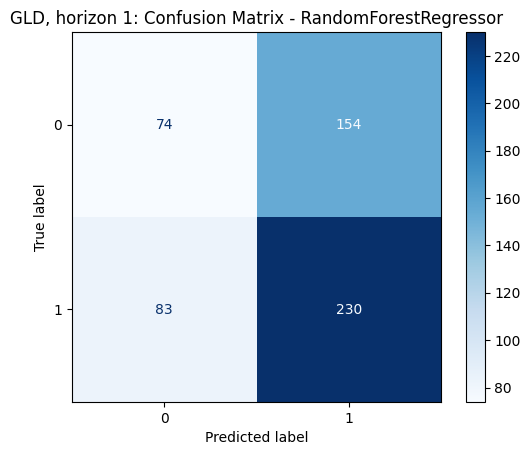

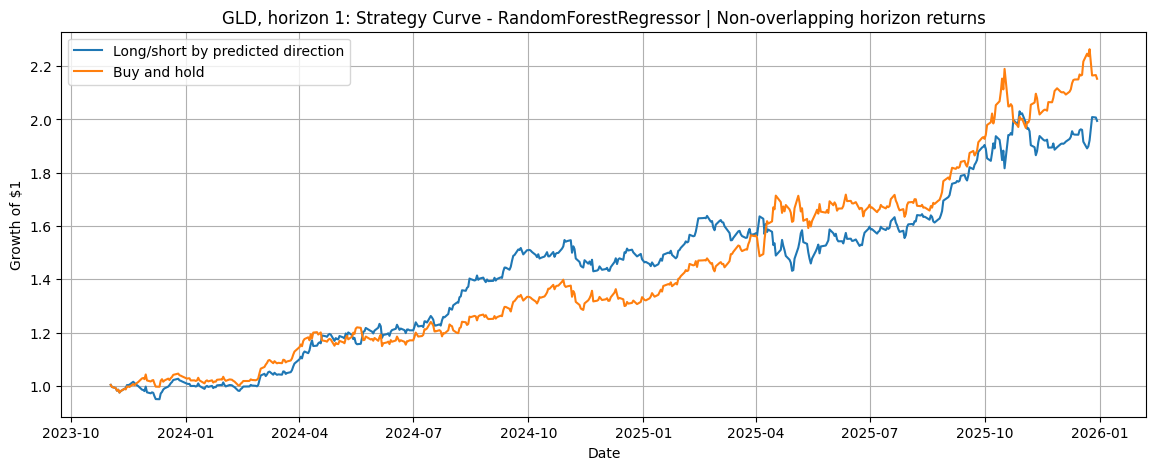


Best model for GLD, horizon 5: RandomForestRegressor
              precision    recall  f1-score   support

   Down/Zero       0.38      0.63      0.47       191
          Up       0.68      0.43      0.53       350

    accuracy                           0.50       541
   macro avg       0.53      0.53      0.50       541
weighted avg       0.58      0.50      0.51       541



<Figure size 600x500 with 0 Axes>

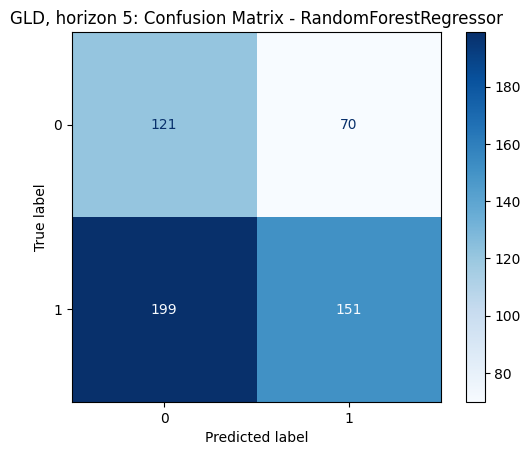

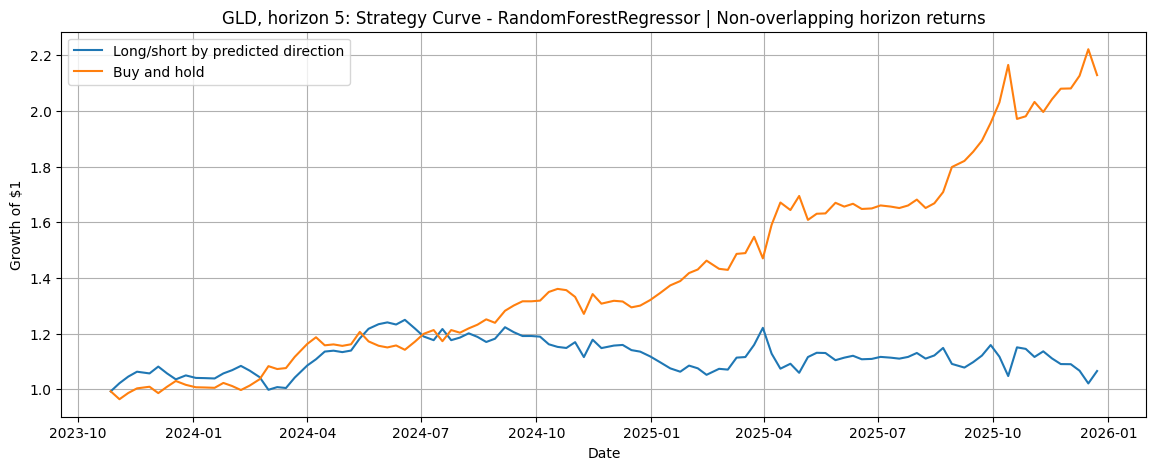


Best model for GLD, horizon 10: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.33      0.49      0.39       174
          Up       0.68      0.52      0.59       366

    accuracy                           0.51       540
   macro avg       0.51      0.51      0.49       540
weighted avg       0.57      0.51      0.53       540



<Figure size 600x500 with 0 Axes>

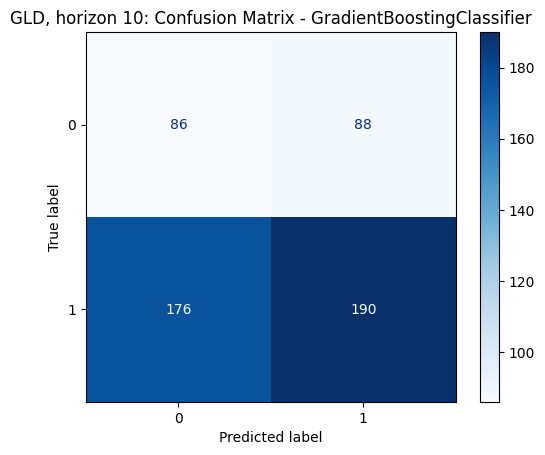

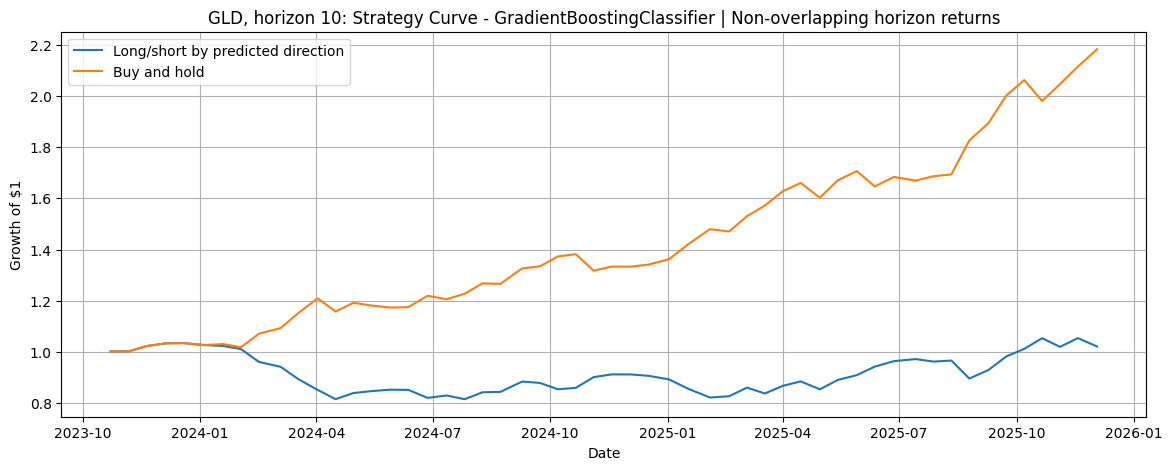


Best model for QQQ, horizon 1: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.38      0.06      0.10       224
          Up       0.58      0.93      0.72       317

    accuracy                           0.57       541
   macro avg       0.48      0.50      0.41       541
weighted avg       0.50      0.57      0.46       541



<Figure size 600x500 with 0 Axes>

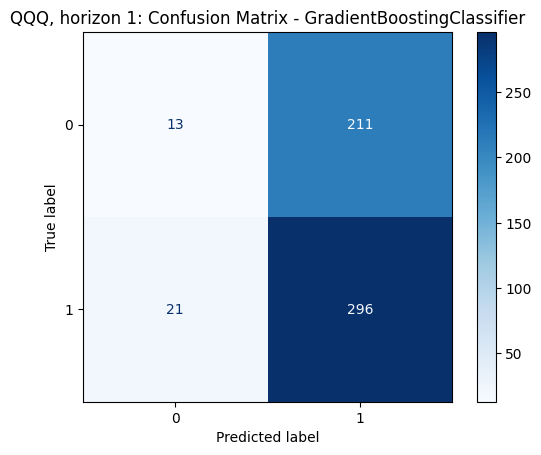

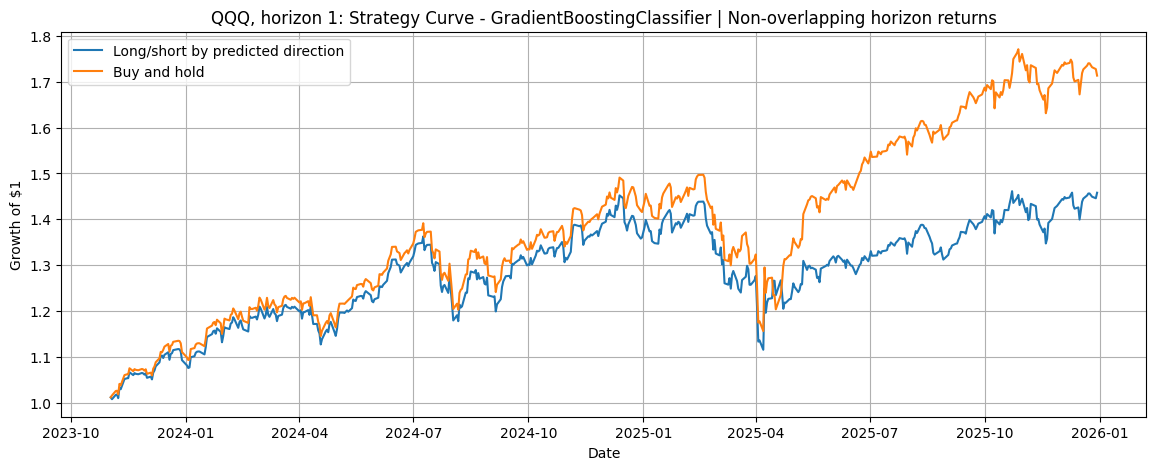


Best model for QQQ, horizon 5: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.51      0.11      0.18       197
          Up       0.65      0.94      0.77       344

    accuracy                           0.64       541
   macro avg       0.58      0.52      0.47       541
weighted avg       0.60      0.64      0.55       541



<Figure size 600x500 with 0 Axes>

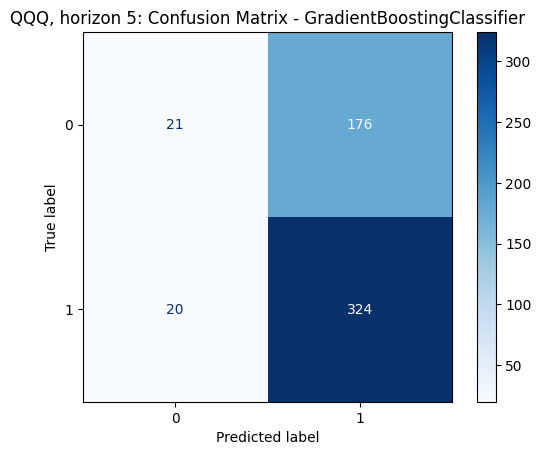

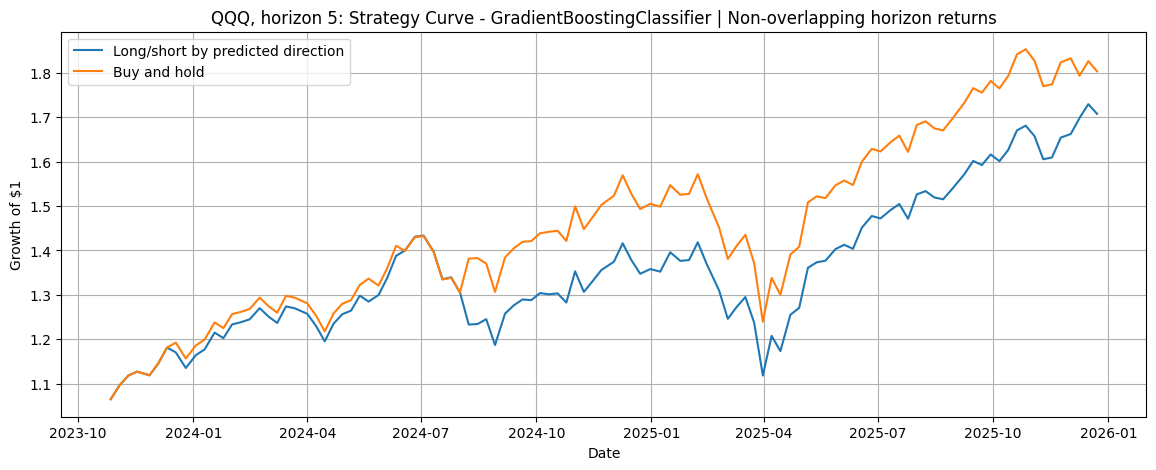


Best model for QQQ, horizon 10: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.42      0.03      0.05       178
          Up       0.67      0.98      0.80       362

    accuracy                           0.67       540
   macro avg       0.54      0.50      0.43       540
weighted avg       0.59      0.67      0.55       540



<Figure size 600x500 with 0 Axes>

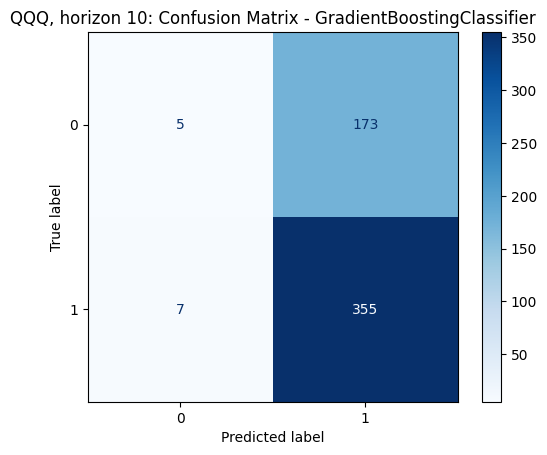

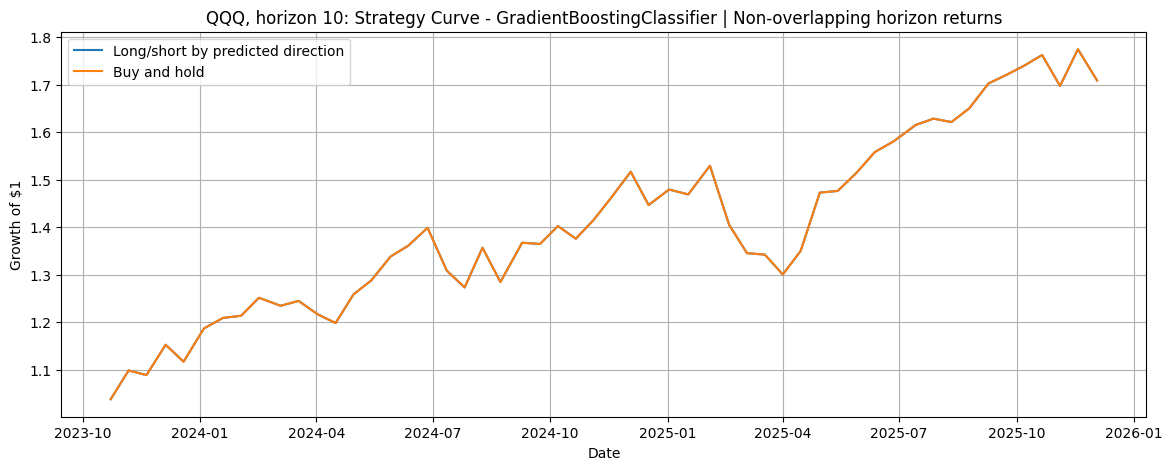


Best model for SPY, horizon 1: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.43      0.09      0.15       222
          Up       0.59      0.92      0.72       319

    accuracy                           0.58       541
   macro avg       0.51      0.50      0.43       541
weighted avg       0.53      0.58      0.49       541



<Figure size 600x500 with 0 Axes>

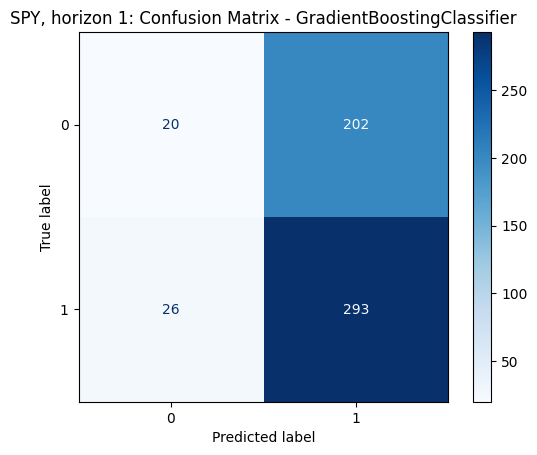

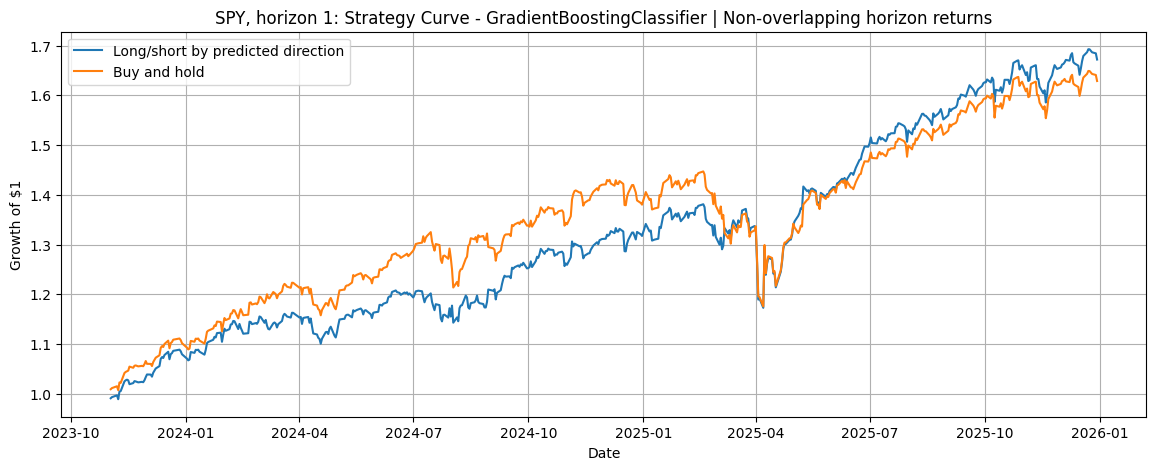


Best model for SPY, horizon 5: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.38      0.07      0.11       181
          Up       0.67      0.94      0.78       360

    accuracy                           0.65       541
   macro avg       0.52      0.51      0.45       541
weighted avg       0.57      0.65      0.56       541



<Figure size 600x500 with 0 Axes>

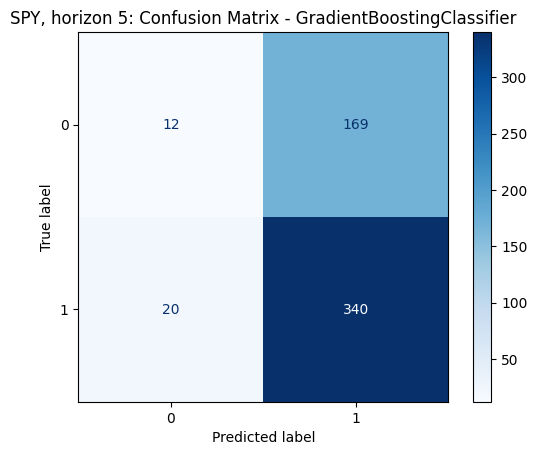

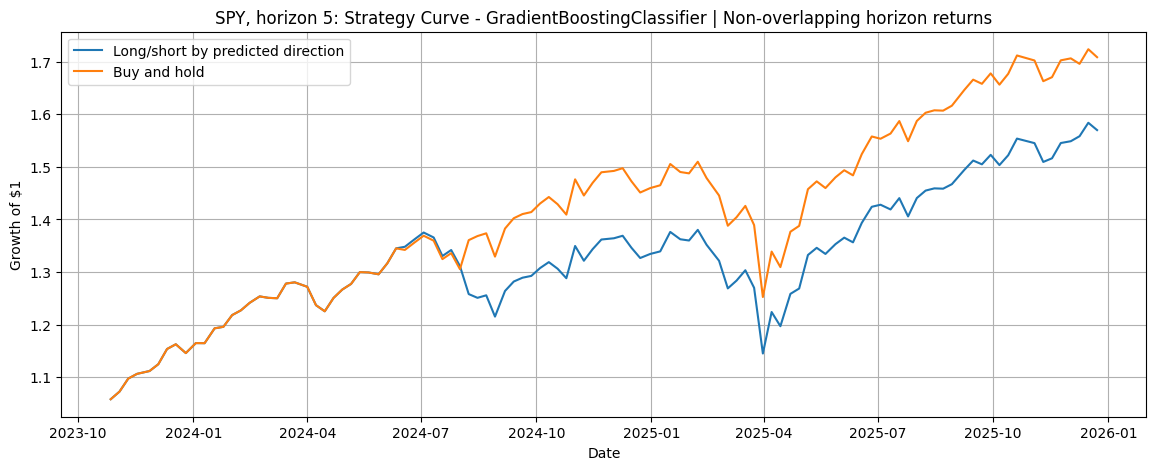


Best model for SPY, horizon 10: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.35      0.11      0.16       160
          Up       0.71      0.92      0.80       380

    accuracy                           0.68       540
   macro avg       0.53      0.51      0.48       540
weighted avg       0.60      0.68      0.61       540



<Figure size 600x500 with 0 Axes>

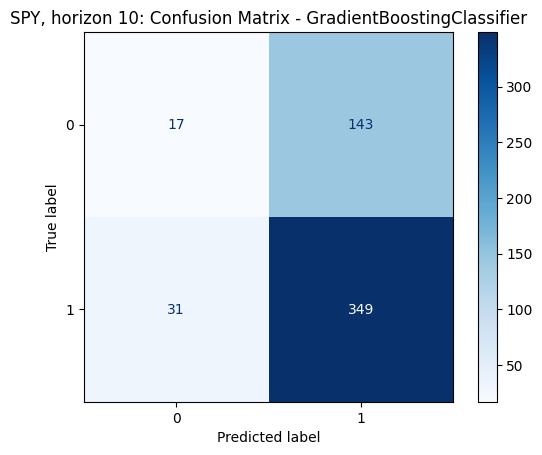

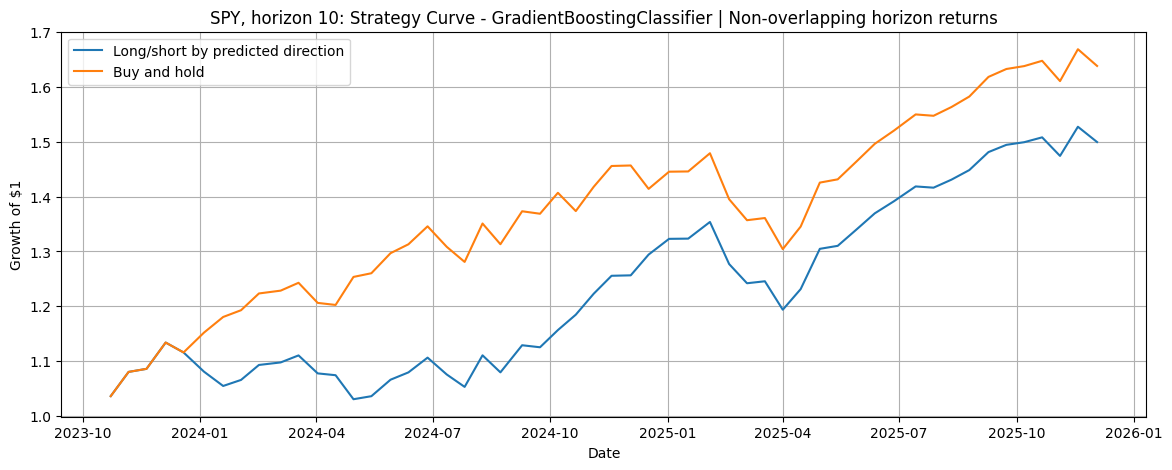


Best model for VOO, horizon 1: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.43      0.10      0.16       221
          Up       0.59      0.91      0.72       320

    accuracy                           0.58       541
   macro avg       0.51      0.50      0.44       541
weighted avg       0.53      0.58      0.49       541



<Figure size 600x500 with 0 Axes>

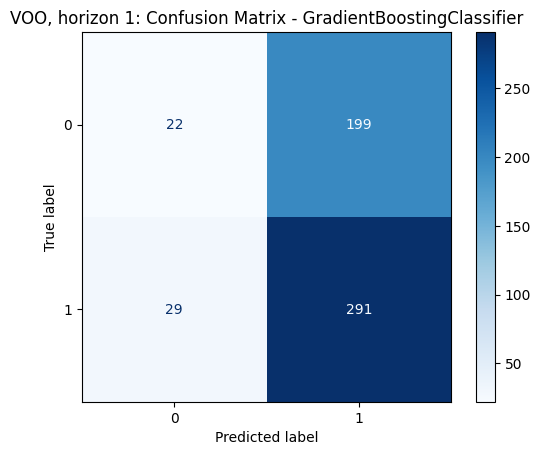

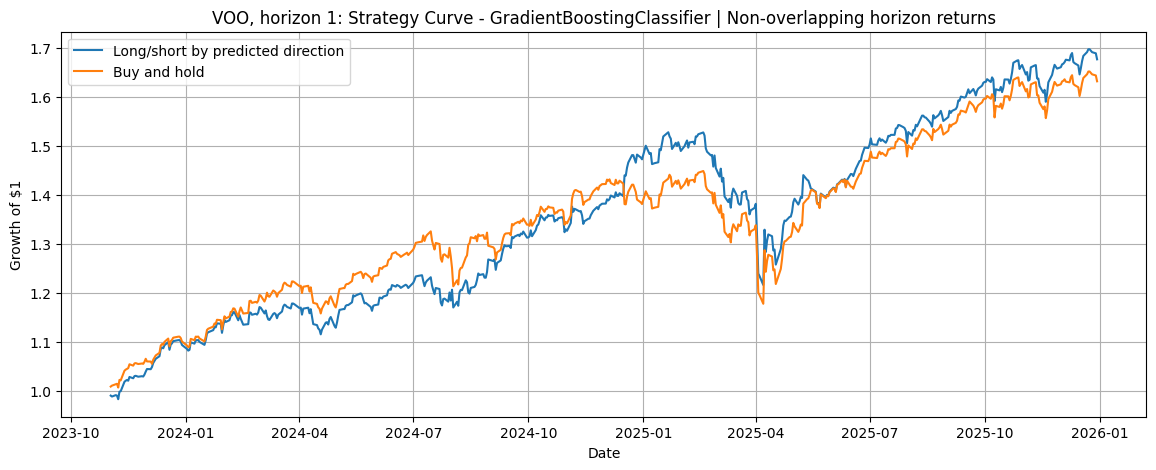


Best model for VOO, horizon 5: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.48      0.08      0.14       181
          Up       0.67      0.96      0.79       360

    accuracy                           0.66       541
   macro avg       0.58      0.52      0.47       541
weighted avg       0.61      0.66      0.57       541



<Figure size 600x500 with 0 Axes>

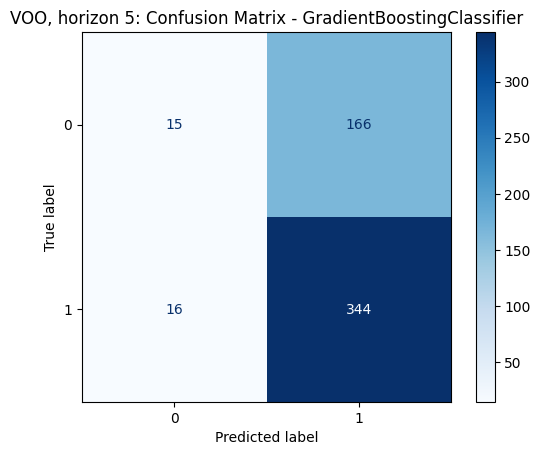

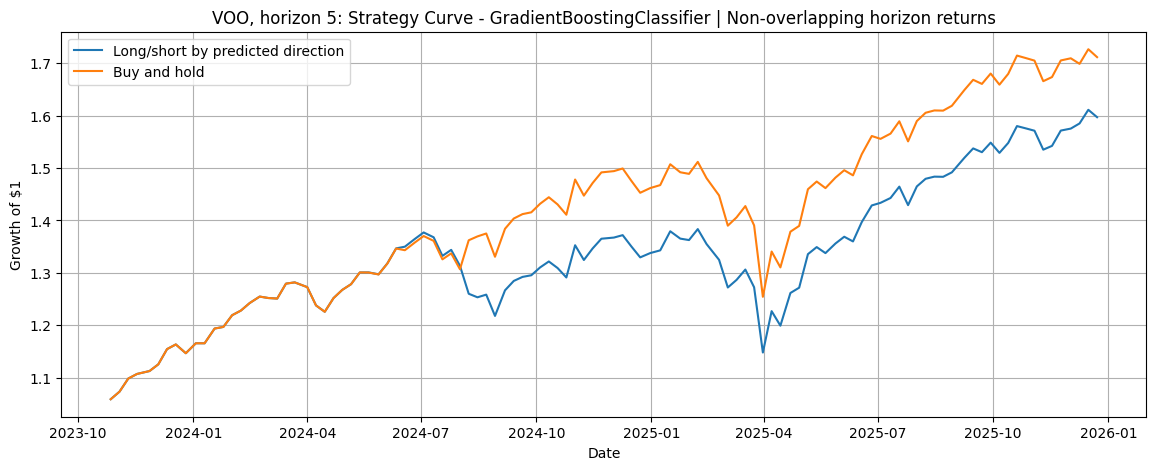


Best model for VOO, horizon 10: GradientBoostingClassifier
              precision    recall  f1-score   support

   Down/Zero       0.29      0.09      0.14       158
          Up       0.71      0.91      0.79       382

    accuracy                           0.67       540
   macro avg       0.50      0.50      0.47       540
weighted avg       0.58      0.67      0.60       540



<Figure size 600x500 with 0 Axes>

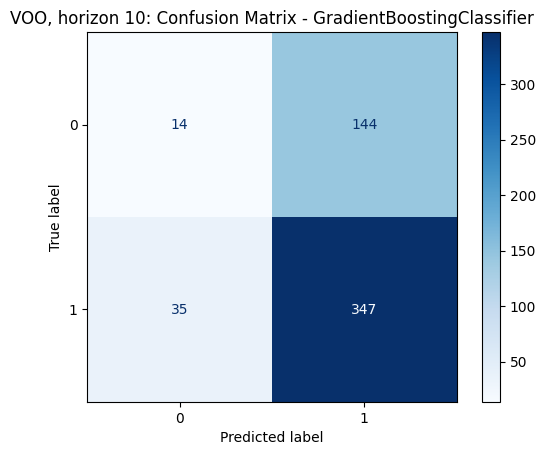

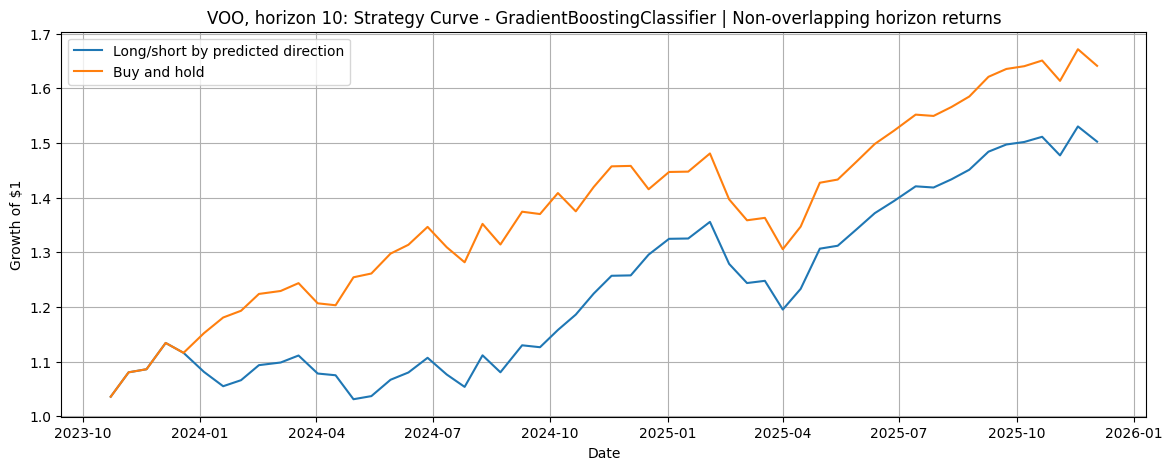

In [27]:
# ============================================================
# 11. Plots for best models
# ============================================================

for _, row in best_by_target_horizon.iterrows():
    target = row["target"]
    horizon = int(row["horizon"])
    model_name = row["model"]
    key = (target, horizon)
    pred_info = all_predictions[key][model_name]

    y_dir_true = pred_info["y_dir"]
    y_ret_true = pred_info["y_ret"]
    prob_up = pred_info["prob_up"]
    dates = pred_info["dates"]

    print("\n" + "=" * 100)
    print(f"Best model for {target}, horizon {horizon}: {model_name}")
    print("=" * 100)
    print(classification_report(y_dir_true, (prob_up >= 0.5).astype(int), target_names=["Down/Zero", "Up"]))

    plot_confusion(
        y_true=y_dir_true,
        prob_up=prob_up,
        title=f"{target}, horizon {horizon}: Confusion Matrix - {model_name}",
    )

    plot_strategy_nonoverlap(
        dates=dates,
        y_forward_return=y_ret_true,
        prob_up=prob_up,
        title=f"{target}, horizon {horizon}: Strategy Curve - {model_name}",
        horizon=horizon,
    )

## 12. Inspect selected features

This helps you discuss whether the feature selection is reasonable. For example, if SPY and VOO are both included, the selector may drop one because they are highly correlated.

In [28]:
# ============================================================
# 12. Inspect selected features
# ============================================================

if not feature_selection_df.empty:
    for target in TARGET_TICKERS:
        for horizon in HORIZONS:
            tmp = feature_selection_df[(feature_selection_df["target"] == target) & (feature_selection_df["horizon"] == horizon)].head(20)
            if len(tmp) > 0:
                print("\n" + "-" * 80)
                print(f"Top selected features: {target}, horizon {horizon}")
                display(tmp[["rank", "feature", "score", "method"]])


--------------------------------------------------------------------------------
Top selected features: SPY, horizon 1


,rank,feature,score,method
0,1,corr_SPY_GLD_20,0.023713,mutual_info
1,2,GLD_roll_mean_60,0.023434,mutual_info
2,3,QQQ_ret_lag_13,0.023419,mutual_info
3,4,SPY_ret_lag_11,0.022449,mutual_info
4,5,GLD_ret_lag_4,0.022179,mutual_info
5,6,QQQ_ret_lag_3,0.020997,mutual_info
6,7,SPY_ret_lag_6,0.018720,mutual_info
7,8,SPY_ret_lag_9,0.018549,mutual_info
8,9,GLD_ret_lag_13,0.018509,mutual_info
9,10,GLD_ret_lag_1,0.018103,mutual_info



--------------------------------------------------------------------------------
Top selected features: SPY, horizon 5


,rank,feature,score,method
80,1,QQQ_roll_min_10,0.218814,mutual_info
81,2,GLD_roll_max_5,0.206042,mutual_info
82,3,QQQ_roll_max_5,0.197091,mutual_info
83,4,GLD_roll_max_10,0.195705,mutual_info
84,5,GLD_roll_min_5,0.194746,mutual_info
85,6,SPY_roll_max_5,0.182604,mutual_info
86,7,QQQ_roll_min_5,0.181094,mutual_info
87,8,SPY_roll_min_10,0.174151,mutual_info
88,9,SPY_roll_min_5,0.171855,mutual_info
89,10,QQQ_roll_max_10,0.156922,mutual_info



--------------------------------------------------------------------------------
Top selected features: SPY, horizon 10


...

,rank,feature,score,method
720,1,GLD_roll_mean_60,0.028518,mutual_info
721,2,GLD_ret_lag_13,0.024303,mutual_info
722,3,QQQ_ret_lag_13,0.020340,mutual_info
723,4,SPY_ret_lag_9,0.019859,mutual_info
724,5,GLD_ret_lag_4,0.019668,mutual_info
725,6,GLD_ret_lag_16,0.018318,mutual_info
726,7,QQQ_ret_lag_3,0.017984,mutual_info
727,8,SPY_ret_lag_6,0.017264,mutual_info
728,9,GLD_ret_lag_1,0.015865,mutual_info
729,10,QQQ_ret_lag_11,0.015818,mutual_info



--------------------------------------------------------------------------------
Top selected features: VOO, horizon 5


,rank,feature,score,method
800,1,QQQ_roll_min_10,0.221613,mutual_info
801,2,GLD_roll_max_5,0.213954,mutual_info
802,3,QQQ_roll_max_5,0.204003,mutual_info
803,4,GLD_roll_max_10,0.198450,mutual_info
804,5,GLD_roll_min_5,0.195041,mutual_info
805,6,SPY_roll_max_5,0.184310,mutual_info
806,7,QQQ_roll_min_5,0.182258,mutual_info
807,8,SPY_roll_min_10,0.180738,mutual_info
808,9,SPY_roll_min_5,0.178132,mutual_info
809,10,QQQ_roll_max_10,0.160727,mutual_info



--------------------------------------------------------------------------------
Top selected features: VOO, horizon 10


,rank,feature,score,method
880,1,QQQ_roll_min_10,0.305838,mutual_info
881,2,SPY_roll_max_5,0.303302,mutual_info
882,3,QQQ_roll_max_10,0.301030,mutual_info
883,4,QQQ_roll_max_5,0.300505,mutual_info
884,5,QQQ_roll_min_5,0.297240,mutual_info
885,6,GLD_roll_min_10,0.296545,mutual_info
886,7,SPY_roll_max_10,0.295452,mutual_info
887,8,GLD_roll_max_10,0.287720,mutual_info
888,9,GLD_roll_min_5,0.287034,mutual_info
889,10,GLD_roll_max_5,0.284013,mutual_info


## 13. Diagnostic: why regression predictions may look flat

If return-regression predictions stay near zero, that is not necessarily a code bug. For daily returns:

1. the true conditional mean is often close to zero;
2. noise dominates the predictable component;
3. MSE loss rewards conservative predictions near the mean;
4. tree models average noisy samples and shrink predictions;
5. with only a few ETFs as input, the feature set may be too weak.

For stronger predictors, consider adding:

- VIX or volatility ETFs;
- Treasury-rate or bond ETF columns such as TLT/IEF;
- sector ETFs such as XLF, XLK, XLE, XLV;
- commodities/FX proxies such as UUP, SLV, USO;
- Fama-French factors if available.

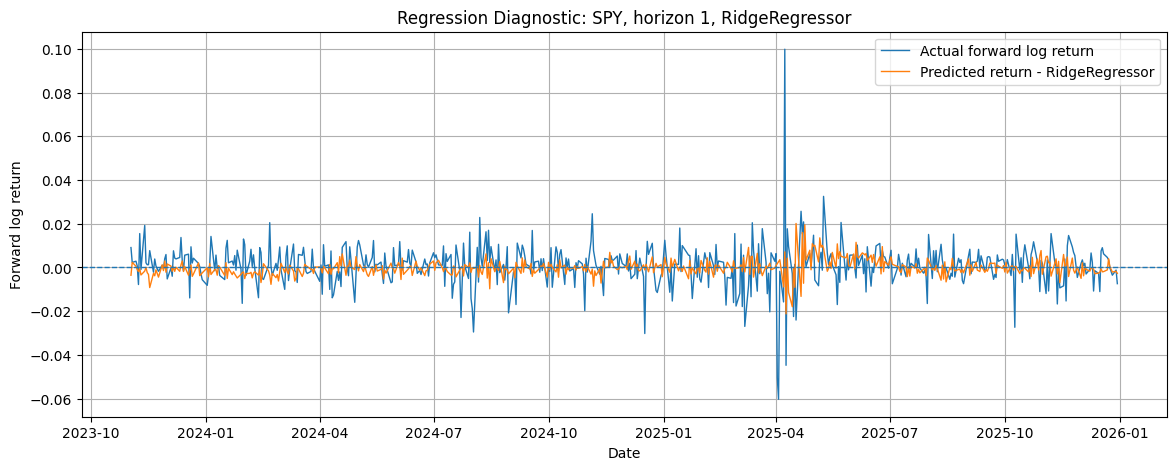

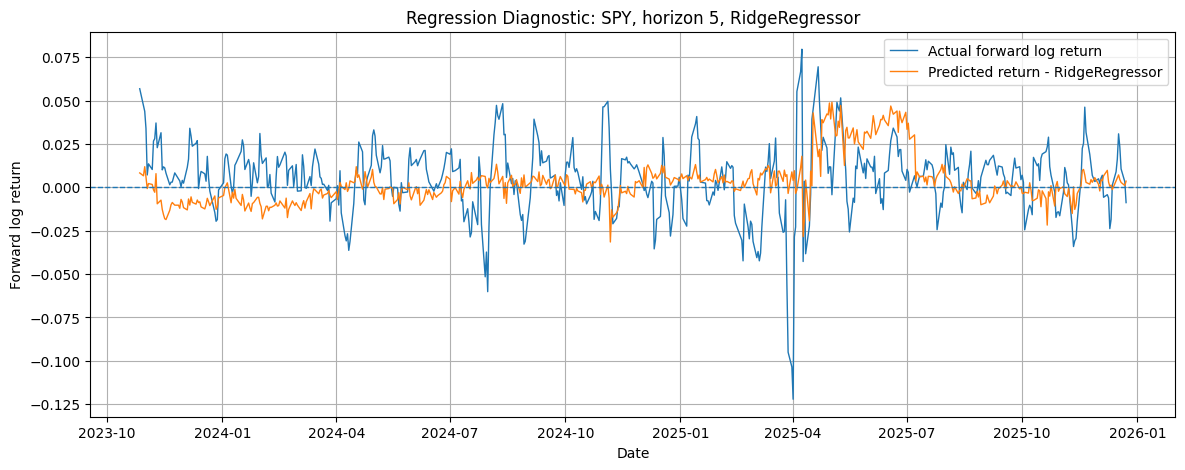

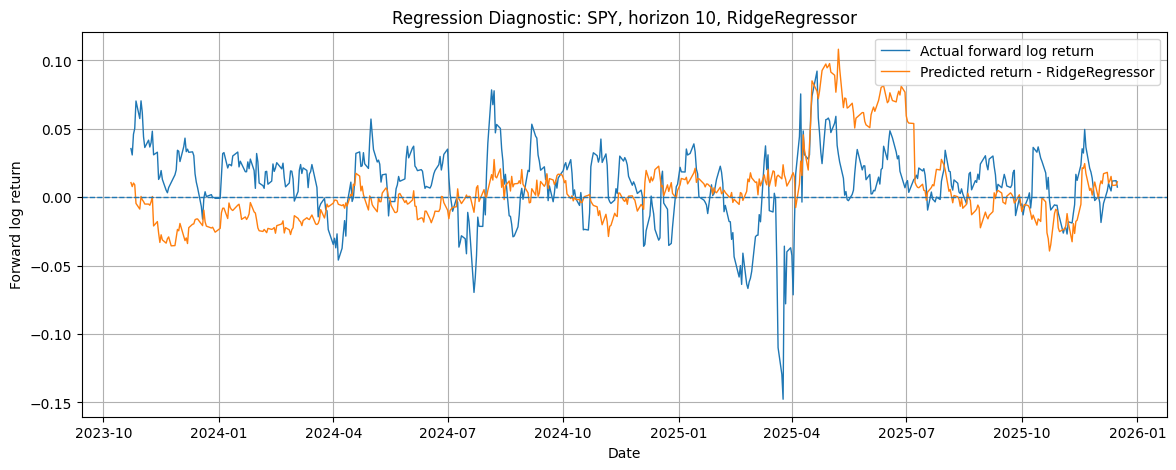

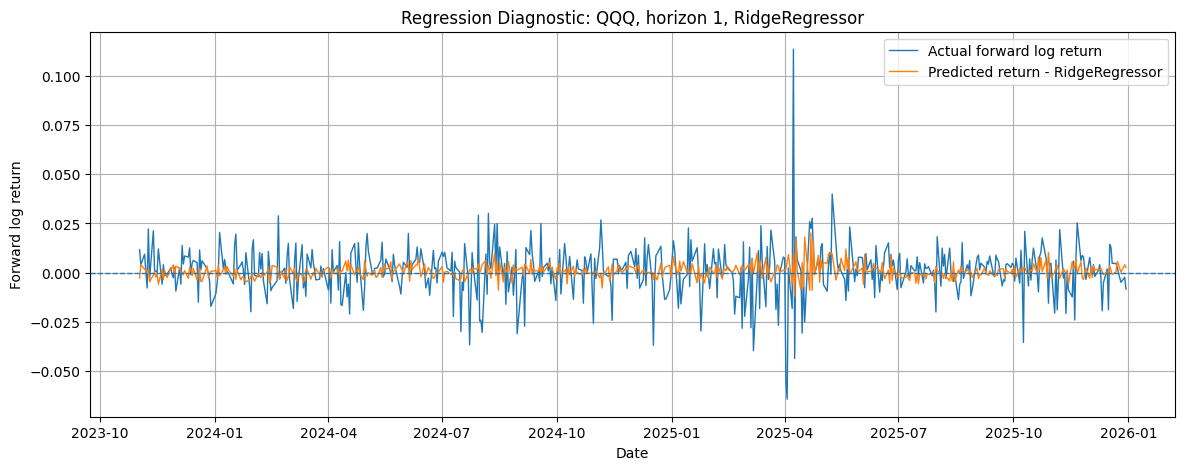

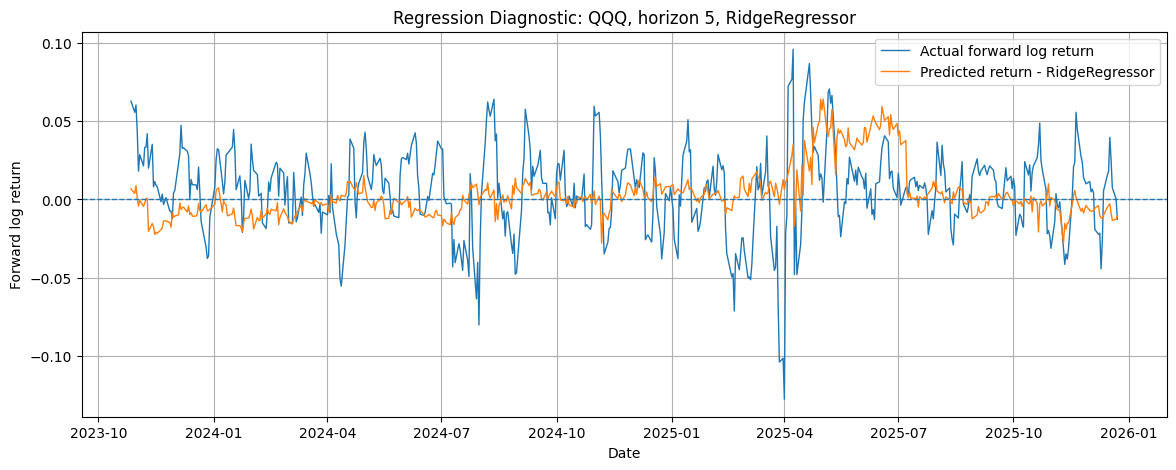

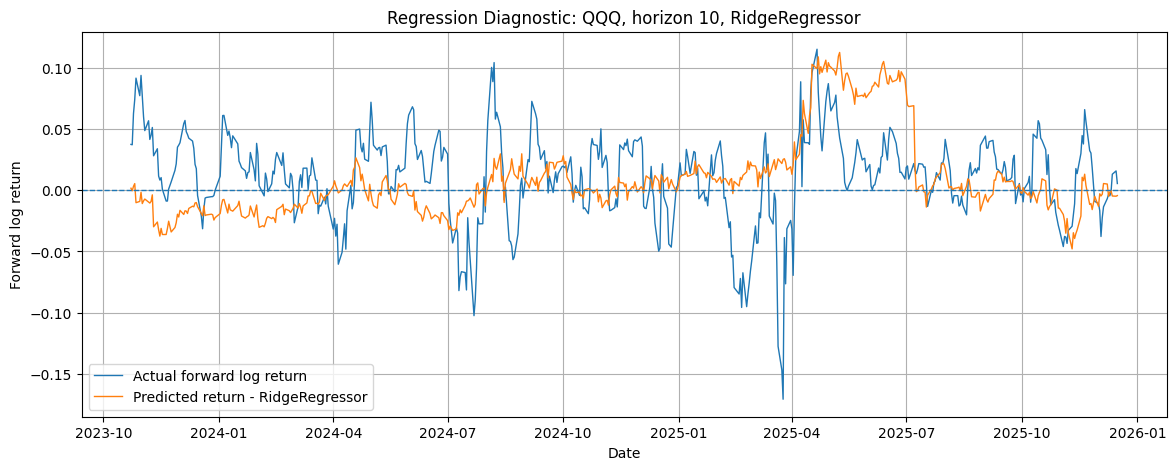

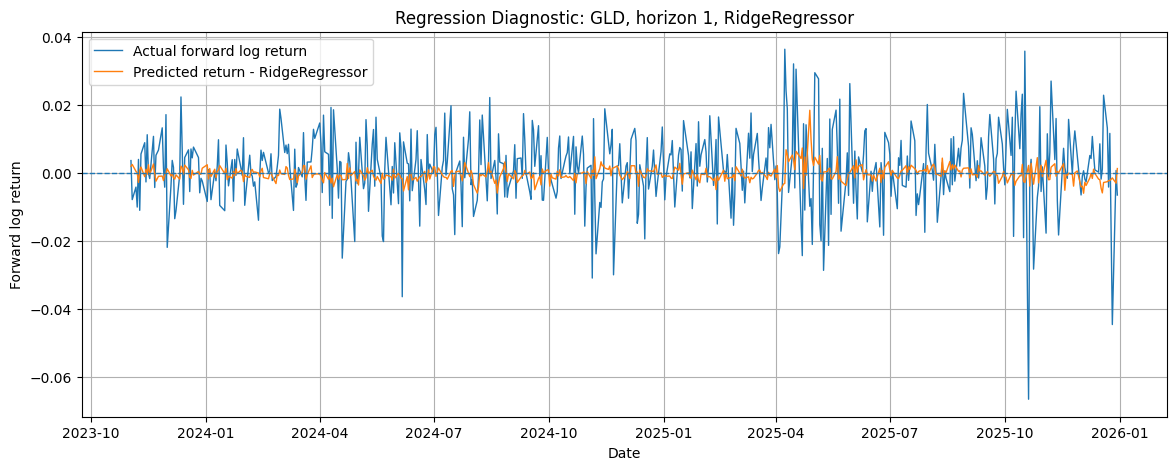

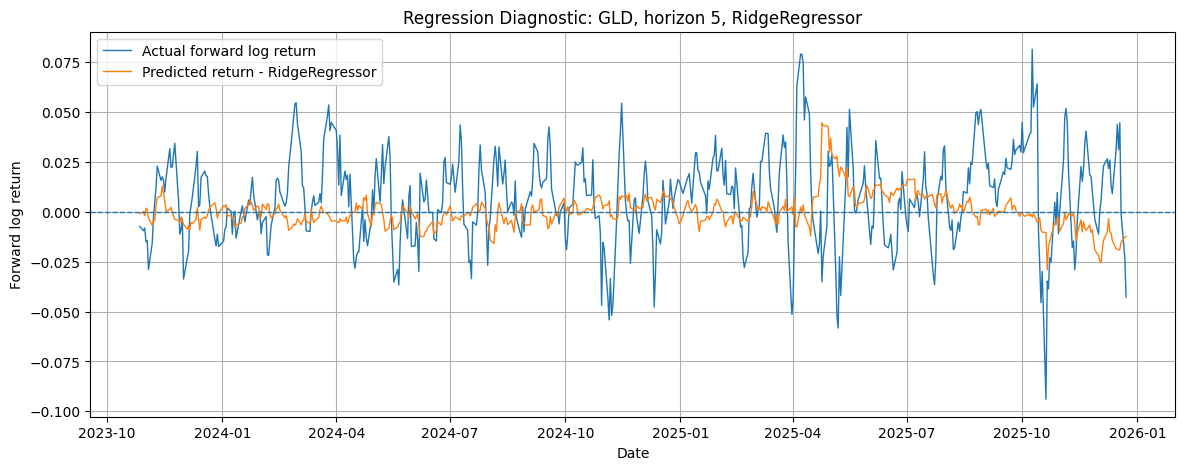

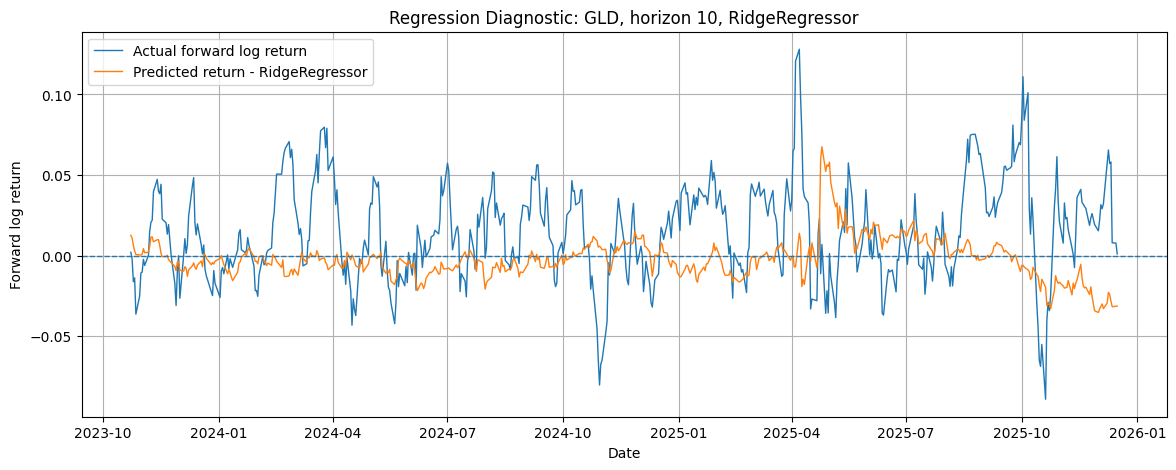

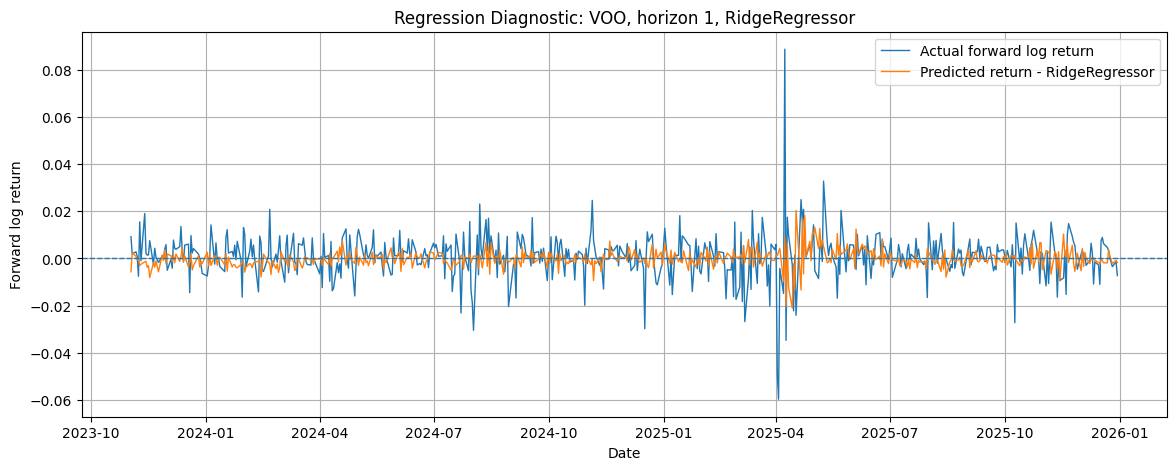

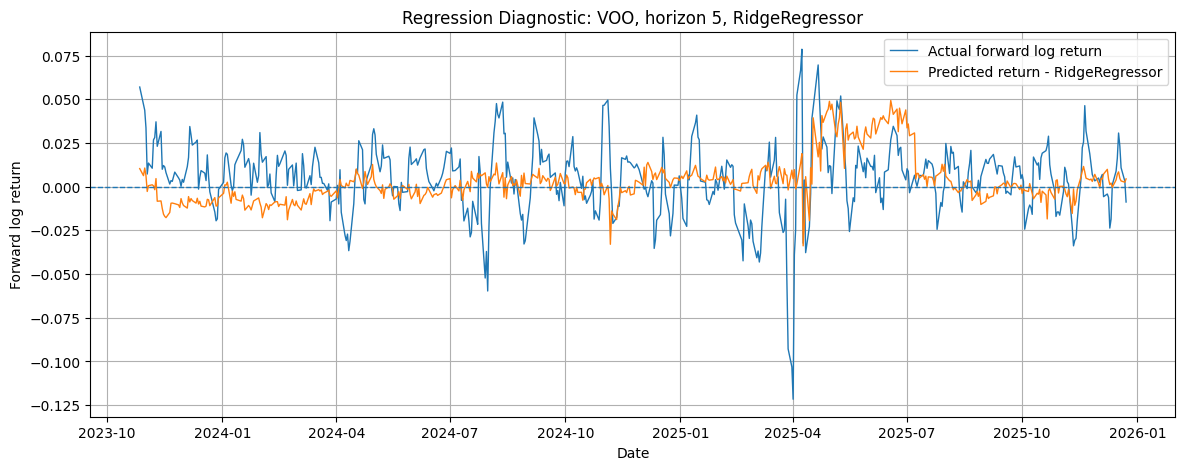

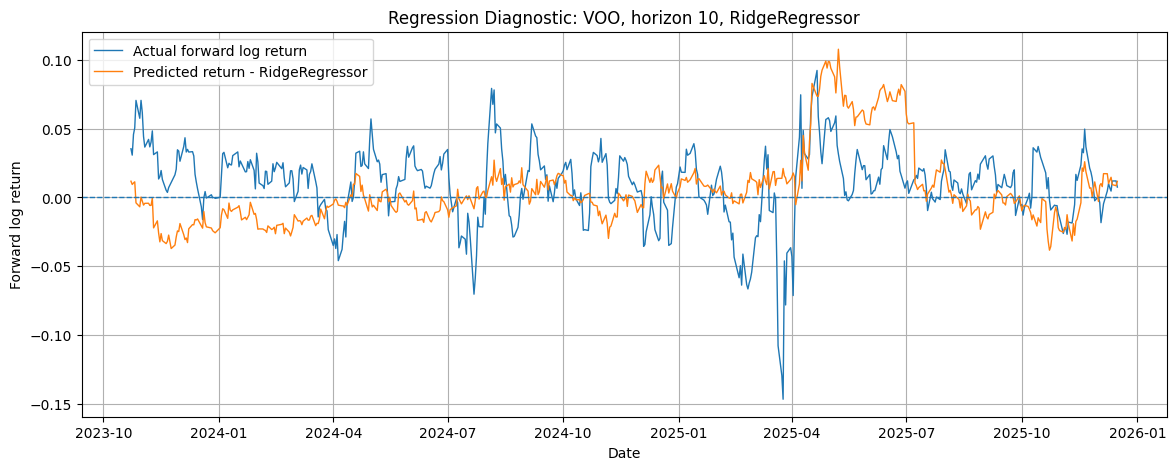

In [29]:
# ============================================================
# 13. Optional regression diagnostic plot
# ============================================================

for key, model_preds in all_predictions.items():
    target, horizon = key
    for model_name, info in model_preds.items():
        if "pred_return" in info:
            plt.figure(figsize=(14, 5))
            plt.plot(info["dates"], info["y_ret"], label="Actual forward log return", linewidth=1)
            plt.plot(info["dates"], info["pred_return"], label=f"Predicted return - {model_name}", linewidth=1)
            plt.axhline(0, linestyle="--", linewidth=1)
            plt.title(f"Regression Diagnostic: {target}, horizon {horizon}, {model_name}")
            plt.xlabel("Date")
            plt.ylabel("Forward log return")
            plt.legend()
            plt.grid(True)
            plt.show()
            break

In [30]:
# ============================================================
# Define export helper for quant integration
# Run this cell BEFORE calling export_row_level_predictions_for_quant(...)
# ============================================================

import os
import numpy as np
import pandas as pd

def export_row_level_predictions_for_quant(
    all_predictions,
    results_df,
    output_path,
    default_model_type="unknown",
):
    """
    Export date-by-date predictions required by 04_quant_integration_backtest.ipynb.

    Expected all_predictions structure:
        all_predictions[(target, horizon)][model_name] = {
            "prob_up": array-like,
            "pred_return": array-like optional,
            "y_dir": array-like,
            "y_ret": array-like,
            "dates": array-like
        }
    """

    rows = []

    # Build model type lookup if possible
    model_type_lookup = {}

    if results_df is not None and not results_df.empty:
        if {"target", "horizon", "model", "model_type"}.issubset(results_df.columns):
            for _, r in results_df.iterrows():
                key = (str(r["target"]), int(r["horizon"]), str(r["model"]))
                model_type_lookup[key] = str(r["model_type"])

    for key, model_dict in all_predictions.items():
        target, horizon = key
        target = str(target)
        horizon = int(horizon)

        for model_name, info in model_dict.items():
            model_name = str(model_name)

            dates_raw = info.get("dates", None)

            if dates_raw is None:
                print(f"Skipping {target}, horizon={horizon}, model={model_name}: missing dates")
                continue

            dates = pd.to_datetime(dates_raw)
            n = len(dates)

            prob_up = np.asarray(info.get("prob_up", [np.nan] * n), dtype=float)
            y_dir = np.asarray(info.get("y_dir", [np.nan] * n), dtype=float)
            y_ret = np.asarray(info.get("y_ret", [np.nan] * n), dtype=float)

            if "pred_return" in info:
                pred_return = np.asarray(info["pred_return"], dtype=float)
            else:
                pred_return = np.full(n, np.nan)

            threshold = info.get("threshold", 0.5)
            long_threshold = info.get("long_threshold", np.nan)
            short_threshold = info.get("short_threshold", np.nan)

            model_type = model_type_lookup.get(
                (target, horizon, model_name),
                default_model_type,
            )

            for i in range(n):
                rows.append({
                    "date": dates[i],
                    "ETF": target,
                    "target": target,
                    "horizon": horizon,
                    "model": model_name,
                    "model_type": model_type,
                    "prob_up": prob_up[i] if i < len(prob_up) else np.nan,
                    "pred_return": pred_return[i] if i < len(pred_return) else np.nan,
                    "actual_direction": y_dir[i] if i < len(y_dir) else np.nan,
                    "actual_forward_return": y_ret[i] if i < len(y_ret) else np.nan,
                    "threshold": threshold,
                    "long_threshold": long_threshold,
                    "short_threshold": short_threshold,
                })

    pred_df = pd.DataFrame(rows)

    if pred_df.empty:
        raise ValueError(
            "No prediction rows were exported. "
            "Check whether all_predictions exists and contains dates/prob_up/y_ret."
        )

    pred_df = pred_df.sort_values(
        ["ETF", "horizon", "model", "date"]
    ).reset_index(drop=True)

    pred_df.to_csv(output_path, index=False)

    print("Saved row-level prediction file:")
    print(output_path)
    print("Shape:", pred_df.shape)
    display(pred_df.head())

    return pred_df

In [31]:
dl_pred_df = export_row_level_predictions_for_quant(
    all_predictions=all_predictions,
    results_df=results_df,
    output_path="/kaggle/working/deep_learning_model_predictions.csv",
    default_model_type="deep_learning",
)

Saved row-level prediction file:
/kaggle/working/deep_learning_model_predictions.csv
Shape: (63140, 13)


,date,ETF,target,horizon,model,model_type,prob_up,pred_return,actual_direction,actual_forward_return,threshold,long_threshold,short_threshold
0,2023-12-14,GLD,GLD,1,Attention_GRU,deep_learning,0.503998,NaN,0.0,-0.009209,0.5,NaN,NaN
1,2023-12-15,GLD,GLD,1,Attention_GRU,deep_learning,0.509995,NaN,1.0,0.004535,0.5,NaN,NaN
2,2023-12-18,GLD,GLD,1,Attention_GRU,deep_learning,0.510075,NaN,1.0,0.006791,0.5,NaN,NaN
3,2023-12-19,GLD,GLD,1,Attention_GRU,deep_learning,0.506105,NaN,0.0,-0.005461,0.5,NaN,NaN
4,2023-12-20,GLD,GLD,1,Attention_GRU,deep_learning,0.495055,NaN,1.0,0.007046,0.5,NaN,NaN


## 14. Suggested report conclusion

A good conclusion should be careful:

> This project reformulates ETF forecasting from exact return-magnitude prediction to multi-horizon direction prediction because ETF returns have low signal-to-noise ratio. Inspired by published ETF and financial deep-learning studies, we compare classical ML models with MLP, LSTM, GRU, CNN-LSTM, and attention-GRU models. Feature selection is fitted only on the training period to reduce redundant lag/rolling predictors and avoid look-ahead bias. Model performance is evaluated by accuracy, balanced accuracy, ROC AUC, F1, confusion matrices, and simple trading-strategy diagnostics. Return-regression metrics are reported as secondary diagnostics because low or negative out-of-sample $R^2$ is common in daily-return prediction.

## References to cite in the report

- Zhong, X., & Enke, D. (2019). Predicting the daily return direction of the stock market using hybrid machine learning algorithms. *Financial Innovation*.
- Zhang, R., Zhao, C., & Lin, G. (2023). Interpretable image-based deep learning for price trend prediction in ETF markets. *The European Journal of Finance*.
- Shih, K. H., Wang, Y. H., Kao, I. C., & Lai, F. M. (2024). Forecasting ETF Performance: A Comparative Study of Deep Learning Models and the Fama-French Three-Factor Model. *Mathematics*.
- Lim, B., Arik, S. O., Loeff, N., & Pfister, T. (2021). Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting. *International Journal of Forecasting*.
- Piovezan, L. G., Andrade Junior, J. R. L., & Ávila, F. D. (2024). Machine Learning Method for Return Direction Forecast of Exchange Traded Funds. *Computational Economics*.